# Notebook 3 — AURKB DeepChem GCN and QSAR–GCN consensus screening

**Article:** Chemotype-aware QSAR–GCN consensus screening and molecular modeling prioritize natural-product-derived AURKB-targeting candidates for pancreatic ductal adenocarcinoma

**Target journal:** Molecular Diversity

**Authors:** The author list, affiliations and corresponding-author details are not recorded in the
manuscript file supplied with this repository and are therefore not reproduced here. They are given in
the submitted manuscript.

**Purpose of this notebook:** Train and validate a DeepChem graph convolutional network as a representation-level adjunct to the descriptor QSAR model, calibrate its probabilities, quantify seed-ensemble uncertainty, and perform rank-based QSAR–GCN consensus prioritization and tiering.

**Workflow stage:** Stage 3 of 3 in the computational screening chain.

**Input:** The exact 6,232-row QSAR-prioritized transfer snapshot produced by Notebook 2.

**Output:** Calibrated GCN validation metrics, consensus scores and tier assignments (Tier 1 = 615, Tier 2 = 3,742, Tier 3 = 936, Tier 4 = 939) and the 29 Tier 1A elite candidates.

**Relationship to the other stages:** Consumes the Notebook 2 transfer snapshot. The 29 Tier 1A candidates were the ligand set for the downstream site-specific AURKB docking, developability/toxicity triage and molecular-dynamics analyses, which were performed outside these notebooks and are not re-run here.

**Frozen-artifact notice:** The scientific state of this study is frozen. This file is a
presentation-only copy of the executed original notebook. Only Markdown text and Python comments were
edited; executable code, cell order, cell identifiers, execution counts and all stored outputs are
unchanged and were not re-executed for this repository. Historical manuscript-authoritative artifacts
are never replaced by values recalculated in a current software environment.

**Executed outputs:** The outputs stored in this notebook are the outputs of the original recorded
execution and are retained for provenance, including environment/version records, warnings and
software-drift evidence.

---


# Notebook 3 — DeepChem GCN, calibrated ensemble uncertainty, and QSAR–GCN consensus screening for AURKB/PDAC

This notebook is module 3 of the AURKB inhibitor-discovery workflow. It consumes the reproducible outputs from Notebook 2 and performs graph-based deep-learning validation and consensus prioritization of candidate AURKB inhibitors for PDAC-focused downstream docking, molecular dynamics, ADMET, and experimental planning.

The workflow separates validation from screening, uses scaffold-disjoint generalization checks, reports classical fingerprint baselines, calibrates neural-network probabilities, estimates ensemble uncertainty, and reports candidates as computational predictions only.


## Methodological safeguards in this notebook

Compared with a simple one-model GCN workflow, this version includes:

1. **Automatic Colab/Drive handling** to reduce path-related failures.
2. **Automatic discovery of the latest Notebook 2 result folder**, with explicit validation of required files.
3. **DeepChem GraphConvModel with ConvMolFeaturizer**, implemented as an orthogonal molecular-graph model.
4. **Random and Bemis–Murcko scaffold-disjoint validation**, with scaffold leakage checks.
5. **Small, transparent hyperparameter search**, selected using validation PR-AUC and ROC-AUC.
6. **ECFP logistic-regression and random-forest baselines** for ablation.
7. **Class-balanced GCN sample weights** to reduce class-imbalance bias.
8. **Validation-based GCN probability calibration** using isotonic regression.
9. **Production ensemble across independent random seeds**, with ensemble standard deviation as uncertainty.
10. **Rank-normalized QSAR–GCN consensus scoring** to avoid overinterpreting raw probability scales.
11. **Nearest-neighbour structural support** against curated AURKB training compounds.
12. **PAINS/Brenk alert reporting and soft drug-likeness annotation** for transparent lead triage.
13. **Docking-ready 3D SDF export** for downstream docking and MD simulation.

Candidate molecules should be described as **in-silico prioritized AURKB inhibitor candidates**, not as experimentally confirmed inhibitors.


## 0. Optional dependency installation

Run this cell only if your environment does not already contain the required packages. For Google Colab, set `INSTALL_DEPENDENCIES = True`. For VS Code/local use, a conda or mamba environment is recommended. DeepChem/TensorFlow installation can be sensitive on native Windows; WSL2 or Linux/Colab is usually more reliable.


In [1]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

print("TF_USE_LEGACY_KERAS =", os.environ.get("TF_USE_LEGACY_KERAS"))

TF_USE_LEGACY_KERAS = 1


In [2]:
# ============================================================
# 0. Colab-safe dependency bootstrap
# ============================================================

import os
import sys
import subprocess
import importlib.util
import platform

AUTO_INSTALL_DEPENDENCIES = True

def _is_colab():
    try:
        import google.colab  # noqa
        return True
    except Exception:
        return False

def _run(cmd):
    print("Running:", " ".join(cmd))
    subprocess.check_call(cmd)

def _can_import(pkg):
    return importlib.util.find_spec(pkg) is not None

print("Runtime Python:", platform.python_version())
print("Colab:", _is_colab())

missing = []
for pkg in ["numpy", "pandas", "sklearn", "rdkit", "tensorflow", "deepchem"]:
    if not _can_import(pkg):
        missing.append(pkg)

print("Missing packages:", missing if missing else "None")

if AUTO_INSTALL_DEPENDENCIES and missing:
    print("\nInstalling dependencies...")

    # Upgrade pip tools first
    _run([sys.executable, "-m", "pip", "install", "-q", "--upgrade", "pip", "setuptools", "wheel"])

    # Install common scientific packages
    _run([
        sys.executable, "-m", "pip", "install", "-q",
        "numpy<2.0",
        "pandas",
        "scikit-learn",
        "matplotlib",
        "joblib",
        "tqdm",
        "protobuf<5"
    ])

    # IMPORTANT: use rdkit, not rdkit-pypi
    _run([
        sys.executable, "-m", "pip", "install", "-q",
        "rdkit"
    ])

    # TensorFlow for Colab Python 3.12
    _run([
        sys.executable, "-m", "pip", "install", "-q",
        "tensorflow",
        "tf-keras"
    ])

    # DeepChem: use pre-release attempt because stable DeepChem often fails on Colab/Python 3.12
    _run([
        sys.executable, "-m", "pip", "install", "-q", "--pre",
        "deepchem"
    ])

    print("\n✅ Installation finished.")

    if _is_colab():
        print("Restarting runtime. After restart, run the notebook from the beginning.")
        os.kill(os.getpid(), 9)

else:
    print("✅ Required packages are already importable.")

Runtime Python: 3.12.13
Colab: True
Missing packages: None
✅ Required packages are already importable.


In [3]:
import sys
import numpy as np
import pandas as pd
import sklearn
import tensorflow as tf
import rdkit
import deepchem as dc

print("Python:", sys.version)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Scikit-learn:", sklearn.__version__)
print("TensorFlow:", tf.__version__)
print("RDKit import: OK")
print("DeepChem:", dc.__version__)

wandb: WARNING W&B installed but not logged in.  Run `wandb login` or set the WANDB_API_KEY env variable.
Instructions for updating:
experimental_relax_shapes is deprecated, use reduce_retracing instead
wandb: WARNING W&B installed but not logged in.  Run `wandb login` or set the WANDB_API_KEY env variable.


Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
NumPy: 1.26.4
Pandas: 2.2.2
Scikit-learn: 1.6.1
TensorFlow: 2.20.0
RDKit import: OK
DeepChem: 2.8.1.dev


## 1. Imports, deterministic settings, and helper utilities


In [4]:
# ============================================================
# 1. Imports, deterministic settings, and helper utilities
# ============================================================

import os
# TensorFlow/Keras compatibility must be set before importing TensorFlow/DeepChem.
os.environ.setdefault("TF_USE_LEGACY_KERAS", "1")
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

import sys
import json
import math
import glob
import time
import random
import shutil
import platform
import datetime
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from IPython.display import display

from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, average_precision_score, balanced_accuracy_score,
    matthews_corrcoef, f1_score, precision_score, recall_score,
    confusion_matrix, brier_score_loss, roc_curve, precision_recall_curve
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import calibration_curve
from sklearn.isotonic import IsotonicRegression

from rdkit import Chem, DataStructs, RDLogger, rdBase
from rdkit.Chem import AllChem, Descriptors, rdMolDescriptors, QED, FilterCatalog, Draw
from rdkit.Chem.Scaffolds import MurckoScaffold

RDLogger.DisableLog("rdApp.warning")

try:
    import tensorflow as tf
    import deepchem as dc
except Exception as e:
    raise ImportError(
        "DeepChem/TensorFlow import failed. In Colab, run the dependency cell with "
        "AUTO_INSTALL_DEPENDENCIES=True and restart the runtime. "
        f"Original error: {e}"
    )

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"Python: {sys.version.split()[0]}")
print(f"Platform: {platform.platform()}")
print(f"NumPy: {np.__version__}")
print(f"Pandas: {pd.__version__}")
print(f"RDKit: {rdBase.rdkitVersion}")
print(f"TensorFlow: {tf.__version__}")
print(f"DeepChem: {dc.__version__}")


# Google Drive mount helper. This is safe outside Colab; it simply does nothing.
try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    print("✅ Google Drive mounted.")
except Exception:
    print("Google Drive mount skipped because this does not appear to be a Colab runtime.")


Python: 3.12.13
Platform: Linux-6.6.122+-x86_64-with-glibc2.35
NumPy: 1.26.4
Pandas: 2.2.2
RDKit: 2026.03.2
TensorFlow: 2.20.0
DeepChem: 2.8.1.dev
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive mounted.


## 2. Configuration

For Colab, this notebook can automatically locate the latest Notebook 2 run folder under:

```text
/content/drive/MyDrive/AURKB_QSAR_Publication_Ready
```

To force a specific Notebook 2 run, set `QSAR_RUN_DIR` to the full folder path. Otherwise leave it as `None`.

The notebook accepts either high-confidence QSAR hits or all inside-applicability-domain compounds from Notebook 2. For the first run, use the high-confidence QSAR subset to reduce GCN runtime.


In [5]:
# ============================================================
# 2. Configuration
# ============================================================

# Main project folder. Change only if your Notebook 2 outputs were saved elsewhere.
PROJECT_ROOT = "/content/drive/MyDrive/AURKB_QSAR_Publication_Ready"

# Leave as None to automatically use the most recently modified Notebook 2 run folder.
# Example manual path:
# QSAR_RUN_DIR = "/content/drive/MyDrive/AURKB_QSAR_Publication_Ready/02_QSAR_ML_20260520_153000"
QSAR_RUN_DIR = None

# Candidate source for GCN consensus:
# False = high-confidence QSAR + inside-AD candidates; recommended first run.
# True  = all QSAR inside-AD candidates; slower but broader.
SCREEN_ALL_INSIDE_AD = False

# Screening and consensus thresholds. These are reported transparently and can be sensitivity-tested.
QSAR_HIGH_CONF_THRESHOLD = 0.75
GCN_PROB_THRESHOLD = 0.60                 # Applied to calibrated GCN probability.
GCN_UNCERTAINTY_MAX_STD = 0.15            # Ensemble standard deviation cutoff.
MIN_TRAIN_SIMILARITY = 0.30               # Morgan Tanimoto structural-support threshold.
TOP_N_EXPORT = 100

# Deep learning settings. Keep the grid small for reproducibility and feasible Colab runtime.
GCN_EPOCHS_SEARCH = 40
GCN_EPOCHS_FINAL = 60
GCN_BATCH_SIZE = 64
GCN_SCREENING_BATCH_SIZE = 1000
ENSEMBLE_SEEDS = [11, 42, 77]

# Set to a smaller number for quick testing, e.g. 2000. Set to None for full selected candidate file.
MAX_SCREENING_COMPOUNDS = None

# Reproducibility seed.
SEED = 42


## 3. Locate Notebook 2 outputs and validate expected files

This cell fails early if the Notebook 2 folder is incorrect. This is intentional: it prevents accidental use of stale files from a previous run.


In [6]:
# ============================================================
# 3. Locate Notebook 2 outputs and validate expected files
# Manual robust mode because training and screening files are in different QSAR folders
# ============================================================

import os, glob, json, datetime
from pathlib import Path

def require_file(path, label):
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing {label}: {path}")
    return path

PROJECT_ROOT = "/content/drive/MyDrive/AURKB_QSAR_Publication_Ready"

# Manually verified from diagnostic output
TRAINING_RUN_DIR = "/content/drive/MyDrive/AURKB_QSAR_Publication_Ready/02_QSAR_ML_20260520_043421"
SCREENING_RUN_DIR = "/content/drive/MyDrive/AURKB_QSAR_Publication_Ready/02_QSAR_ML_20260520_045612"

curated_path = require_file(
    "/content/drive/MyDrive/AURKB_QSAR_Publication_Ready/02_QSAR_ML_20260520_043421/tables/curated_AURKB_training_data.csv",
    "curated AURKB training data"
)

# Prefer high-confidence inside-AD QSAR candidates for stricter consensus screening
screening_path = require_file(
    "/content/drive/MyDrive/AURKB_QSAR_Publication_Ready/02_QSAR_ML_20260520_045612/AURKB_QSAR_high_confidence_inside_AD_prob075.csv",
    "high-confidence inside-AD QSAR screening candidates"
)

# Optional QSAR model file
possible_qsar_models = sorted(
    glob.glob(os.path.join(SCREENING_RUN_DIR, "**", "AURKB_QSAR_production_calibrated_model.joblib"), recursive=True)
    + glob.glob(os.path.join(TRAINING_RUN_DIR, "**", "AURKB_QSAR_production_calibrated_model.joblib"), recursive=True)
)

qsar_model_path = possible_qsar_models[0] if possible_qsar_models else None

# Output folder should be created inside the screening run folder because consensus results are screening-related
RUN_ID = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
DEEP_RUN_DIR = os.path.join(SCREENING_RUN_DIR, f"03_DeepChem_GCN_Consensus_{RUN_ID}")
FIG_DIR = os.path.join(DEEP_RUN_DIR, "figures")
TABLE_DIR = os.path.join(DEEP_RUN_DIR, "tables")
MODEL_DIR = os.path.join(DEEP_RUN_DIR, "gcn_models")

for d in [DEEP_RUN_DIR, FIG_DIR, TABLE_DIR, MODEL_DIR]:
    os.makedirs(d, exist_ok=True)

CONFIG = {
    "project_root": PROJECT_ROOT,
    "training_run_dir": TRAINING_RUN_DIR,
    "screening_run_dir": SCREENING_RUN_DIR,
    "curated_training_data": curated_path,
    "screening_candidates": screening_path,
    "qsar_model_path": qsar_model_path,
    "note": "Manual robust mode used because curated training data and QSAR screening outputs were found in different Notebook 2 run folders."
}

with open(os.path.join(DEEP_RUN_DIR, "deepchem_consensus_run_config.json"), "w") as f:
    json.dump(CONFIG, f, indent=2)

print("\n✅ Input files validated")
print("- Curated training:", curated_path)
print("- Screening candidates:", screening_path)
print("- QSAR model:", qsar_model_path if qsar_model_path else "Not found / not required in this notebook")

print("\n✅ DeepChem/consensus output folder:")
print(DEEP_RUN_DIR)


✅ Input files validated
- Curated training: /content/drive/MyDrive/AURKB_QSAR_Publication_Ready/02_QSAR_ML_20260520_043421/tables/curated_AURKB_training_data.csv
- Screening candidates: /content/drive/MyDrive/AURKB_QSAR_Publication_Ready/02_QSAR_ML_20260520_045612/AURKB_QSAR_high_confidence_inside_AD_prob075.csv
- QSAR model: /content/drive/MyDrive/AURKB_QSAR_Publication_Ready/02_QSAR_ML_20260520_043421/model_artifacts/AURKB_QSAR_production_calibrated_model.joblib

✅ DeepChem/consensus output folder:
/content/drive/MyDrive/AURKB_QSAR_Publication_Ready/02_QSAR_ML_20260520_045612/03_DeepChem_GCN_Consensus_20260521_074502


## 4. Load curated AURKB activity data and QSAR candidate set


In [7]:
def detect_smiles_column(df):
    for c in ["smiles_std", "smiles", "canonical_smiles", "SMILES", "standardized_smiles"]:
        if c in df.columns:
            return c
    raise ValueError(f"No SMILES column found. Available columns: {list(df.columns)}")

def detect_label_column(df):
    for c in ["y", "activity_label", "active", "label"]:
        if c in df.columns:
            return c
    raise ValueError(f"No activity-label column found. Available columns: {list(df.columns)}")

def standardize_smiles(smi):
    try:
        mol = Chem.MolFromSmiles(str(smi))
        if mol is None:
            return None
        # Keep largest fragment to avoid salts/counterions.
        frags = Chem.GetMolFrags(mol, asMols=True, sanitizeFrags=True)
        if len(frags) > 1:
            mol = max(frags, key=lambda m: m.GetNumHeavyAtoms())
        Chem.SanitizeMol(mol)
        return Chem.MolToSmiles(mol, isomericSmiles=True, canonical=True)
    except Exception:
        return None

# Curated training set from Notebook 2
df_train = pd.read_csv(curated_path)
train_smi_col = detect_smiles_column(df_train)
label_col = detect_label_column(df_train)

df_train["smiles_gcn"] = df_train[train_smi_col].apply(standardize_smiles)
df_train = df_train[df_train["smiles_gcn"].notna()].copy()

# Convert labels robustly. If activity_label is text, map active/inactive.
if df_train[label_col].dtype == object:
    df_train["y"] = df_train[label_col].astype(str).str.lower().map({"active": 1, "inactive": 0, "1": 1, "0": 0})
else:
    df_train["y"] = df_train[label_col].astype(int)

df_train = df_train[df_train["y"].isin([0, 1])].drop_duplicates("smiles_gcn").reset_index(drop=True)

# Screening candidates from Notebook 2
candidate_df = pd.read_csv(screening_path)
cand_smi_col = detect_smiles_column(candidate_df)
candidate_df["smiles"] = candidate_df[cand_smi_col].apply(standardize_smiles)
candidate_df = candidate_df[candidate_df["smiles"].notna()].drop_duplicates("smiles").reset_index(drop=True)

# Harmonize QSAR probability column
if "prob_active_qsar" not in candidate_df.columns:
    for c in ["prob_active", "qsar_probability", "probability_active", "prediction_probability"]:
        if c in candidate_df.columns:
            candidate_df = candidate_df.rename(columns={c: "prob_active_qsar"})
            break
if "prob_active_qsar" not in candidate_df.columns:
    raise ValueError("Candidate file must contain prob_active_qsar or equivalent QSAR probability column.")

if "inside_AD" not in candidate_df.columns:
    raise ValueError("Candidate file must contain inside_AD from Notebook 2.")

def parse_bool_value(x):
    if isinstance(x, (bool, np.bool_)):
        return bool(x)
    if pd.isna(x):
        return False
    if isinstance(x, (int, float, np.integer, np.floating)):
        return bool(int(x))
    return str(x).strip().lower() in {"true", "1", "yes", "y", "t"}

candidate_df["inside_AD"] = candidate_df["inside_AD"].apply(parse_bool_value)

if MAX_SCREENING_COMPOUNDS is not None:
    candidate_df = candidate_df.sort_values("prob_active_qsar", ascending=False).head(MAX_SCREENING_COMPOUNDS).copy()

print("Training data")
print(df_train["y"].value_counts().rename(index={0: "inactive", 1: "active"}))
print(f"Unique training structures: {len(df_train):,}")
print("\nScreening candidates")
print(f"Unique candidate structures: {len(candidate_df):,}")
print(candidate_df[["smiles", "prob_active_qsar", "inside_AD"]].head())

# Save harmonized input audit
train_audit_path = os.path.join(TABLE_DIR, "gcn_training_input_audit.csv")
cand_audit_path = os.path.join(TABLE_DIR, "gcn_candidate_input_audit.csv")
df_train.to_csv(train_audit_path, index=False)
candidate_df.to_csv(cand_audit_path, index=False)


Training data
y
active      1429
inactive     425
Name: count, dtype: int64
Unique training structures: 1,854

Screening candidates
Unique candidate structures: 6,232
                                              smiles  prob_active_qsar  \
0  O=C(Cn1nc(Cl)ccc1=O)Nc1ccc(C(=O)NC[C@@H]2CCCN3...          0.945540   
1   O=C(CCc1nc2cc(Br)cnc2[nH]1)NC[C@@H]1CCCN2CCCCC12          0.945272   
2  NC(=O)Cc1csc(NC(=O)CCCN2C(=O)c3ccccc3N3C(=O)c4...          0.944537   
3  O=C(Cn1cnc2c(N3CCCCC3)nc(Cl)nc21)NC[C@@H]1CCCN...          0.943971   
4  O=C(N[C@H]1CCN2C(=O)c3cc(/C=C/c4ccccc4)ccc3NC(...          0.943900   

   inside_AD  
0       True  
1       True  
2       True  
3       True  
4       True  


## 5. Molecular scaffolds and scaffold-disjoint splitting

Random splits can overestimate molecular-model performance when close analogues occur in both training and test sets. The scaffold-disjoint split evaluates generalization to chemotypes absent from training.


In [8]:
def murcko_scaffold_smiles(smi):
    try:
        mol = Chem.MolFromSmiles(str(smi))
        if mol is None:
            return ""
        scaf = MurckoScaffold.GetScaffoldForMol(mol)
        return Chem.MolToSmiles(scaf, canonical=True) if scaf is not None else ""
    except Exception:
        return ""

def scaffold_three_way_split(df, smiles_col="smiles_gcn", label_col="y", test_size=0.20, val_size=0.20, seed=42):
    # Group molecules by Bemis-Murcko scaffold, then assign whole scaffold groups to test/val/train.
    rng = np.random.default_rng(seed)
    tmp = df.copy()
    tmp["scaffold"] = tmp[smiles_col].apply(murcko_scaffold_smiles)
    # Treat acyclic molecules with empty scaffold as their own standardized SMILES group to avoid one giant group.
    tmp.loc[tmp["scaffold"] == "", "scaffold"] = "acyclic_" + tmp.loc[tmp["scaffold"] == "", smiles_col]

    groups = []
    for scaf, sub in tmp.groupby("scaffold"):
        groups.append((scaf, sub.index.to_numpy(), len(sub), sub[label_col].mean()))
    # Large scaffolds first; shuffle ties to make deterministic but not sorted by class.
    rng.shuffle(groups)
    groups = sorted(groups, key=lambda x: x[2], reverse=True)

    n_total = len(tmp)
    n_test_target = int(round(test_size * n_total))
    n_val_target = int(round(val_size * n_total))

    test_idx, val_idx, train_idx = [], [], []
    for scaf, idxs, size, frac_active in groups:
        if len(test_idx) < n_test_target:
            test_idx.extend(idxs.tolist())
        elif len(val_idx) < n_val_target:
            val_idx.extend(idxs.tolist())
        else:
            train_idx.extend(idxs.tolist())

    return np.array(train_idx), np.array(val_idx), np.array(test_idx), tmp["scaffold"]

# Random train/validation/test split
all_idx = np.arange(len(df_train))
y_all = df_train["y"].values
idx_train_rand, idx_temp_rand = train_test_split(all_idx, test_size=0.40, stratify=y_all, random_state=SEED)
idx_val_rand, idx_test_rand = train_test_split(
    idx_temp_rand,
    test_size=0.50,
    stratify=y_all[idx_temp_rand],
    random_state=SEED,
)

# Scaffold train/validation/test split
idx_train_scaf, idx_val_scaf, idx_test_scaf, scaffolds = scaffold_three_way_split(df_train, seed=SEED)
df_train["scaffold"] = scaffolds

def split_summary(name, train_idx, val_idx, test_idx):
    rows = []
    for split_name, idxs in [("train", train_idx), ("validation", val_idx), ("test", test_idx)]:
        y = df_train.loc[idxs, "y"]
        rows.append({
            "split_scheme": name,
            "split": split_name,
            "n": len(idxs),
            "active": int((y == 1).sum()),
            "inactive": int((y == 0).sum()),
            "active_fraction": float(y.mean()),
            "n_scaffolds": int(df_train.loc[idxs, "scaffold"].nunique()),
        })
    return rows

split_rows = []
split_rows.extend(split_summary("random", idx_train_rand, idx_val_rand, idx_test_rand))
split_rows.extend(split_summary("scaffold", idx_train_scaf, idx_val_scaf, idx_test_scaf))
split_df = pd.DataFrame(split_rows)
split_df.to_csv(os.path.join(TABLE_DIR, "gcn_split_summary.csv"), index=False)

print(split_df)

# Check scaffold leakage in scaffold split
train_scaff = set(df_train.loc[idx_train_scaf, "scaffold"])
val_scaff = set(df_train.loc[idx_val_scaf, "scaffold"])
test_scaff = set(df_train.loc[idx_test_scaf, "scaffold"])
print("\nScaffold overlap check:")
print("train ∩ val:", len(train_scaff & val_scaff))
print("train ∩ test:", len(train_scaff & test_scaff))
print("val ∩ test:", len(val_scaff & test_scaff))


  split_scheme       split     n  active  inactive  active_fraction  \
0       random       train  1112     857       255         0.770683   
1       random  validation   371     286        85         0.770889   
2       random        test   371     286        85         0.770889   
3     scaffold       train  1109     811       298         0.731289   
4     scaffold  validation   371     289        82         0.778976   
5     scaffold        test   374     329        45         0.879679   

   n_scaffolds  
0          612  
1          271  
2          274  
3          824  
4           54  
5           17  

Scaffold overlap check:
train ∩ val: 0
train ∩ test: 0
val ∩ test: 0


## 6. DeepChem graph featurization

Molecules are represented as graphs using DeepChem `ConvMolFeaturizer`, where atoms and bonds define graph nodes and connectivity for graph convolution.


In [9]:
# ============================================================
# 6. DeepChem graph featurization
# ============================================================

featurizer = dc.feat.ConvMolFeaturizer()

def is_valid_graph_object(g):
    """Robust validity check for DeepChem ConvMol objects."""
    if g is None:
        return False
    # Failed DeepChem featurizations may return empty arrays/lists rather than None.
    if isinstance(g, (list, tuple, np.ndarray)) and len(g) == 0:
        return False
    if hasattr(g, "get_num_atoms"):
        try:
            return g.get_num_atoms() > 0
        except Exception:
            return False
    return True

print("Featurizing curated training molecules...")
X_graph = featurizer.featurize(df_train["smiles_gcn"].tolist())
X_graph = np.asarray(X_graph, dtype=object)
valid_graph_mask = np.array([is_valid_graph_object(x) for x in X_graph], dtype=bool)

if valid_graph_mask.sum() != len(df_train):
    print(f"Dropping {len(df_train) - valid_graph_mask.sum()} structures that failed graph featurization.")
    df_train = df_train.loc[valid_graph_mask].reset_index(drop=True)
    X_graph = X_graph[valid_graph_mask]

    # Recreate splits after dropping failures.
    all_idx = np.arange(len(df_train))
    y_all = df_train["y"].astype(int).values
    idx_train_rand, idx_temp_rand = train_test_split(all_idx, test_size=0.40, stratify=y_all, random_state=SEED)
    idx_val_rand, idx_test_rand = train_test_split(
        idx_temp_rand, test_size=0.50, stratify=y_all[idx_temp_rand], random_state=SEED
    )
    idx_train_scaf, idx_val_scaf, idx_test_scaf, scaffolds = scaffold_three_way_split(df_train, seed=SEED)
    df_train["scaffold"] = scaffolds

    # Update split summary after featurization filtering.
    split_rows = []
    split_rows.extend(split_summary("random_after_graph_featurization", idx_train_rand, idx_val_rand, idx_test_rand))
    split_rows.extend(split_summary("scaffold_after_graph_featurization", idx_train_scaf, idx_val_scaf, idx_test_scaf))
    pd.DataFrame(split_rows).to_csv(os.path.join(TABLE_DIR, "gcn_split_summary_after_featurization.csv"), index=False)

print(f"Graph-featurized molecules: {len(X_graph):,}")


Featurizing curated training molecules...
Graph-featurized molecules: 1,854


## 7. Metric and dataset helper functions


In [15]:
# ============================================================
# Scaffold-aware train/validation/test split using existing scaffold column
# ============================================================

import numpy as np
from collections import defaultdict

df_train = df_train.reset_index(drop=True).copy()

# Confirm required columns
required_cols = ["smiles_gcn", "y", "scaffold"]
missing_cols = [c for c in required_cols if c not in df_train.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

# Group molecule indices by scaffold
scaffold_to_indices = defaultdict(list)

for idx, scaffold in enumerate(df_train["scaffold"].astype(str).values):
    scaffold_to_indices[scaffold].append(idx)

# Sort largest scaffold groups first
scaffold_groups = sorted(
    scaffold_to_indices.values(),
    key=lambda x: len(x),
    reverse=True
)

n_total = len(df_train)
target_train = int(0.80 * n_total)
target_valid = int(0.10 * n_total)

train_idx, valid_idx, test_idx = [], [], []

for group in scaffold_groups:
    if len(train_idx) + len(group) <= target_train:
        train_idx.extend(group)
    elif len(valid_idx) + len(group) <= target_valid:
        valid_idx.extend(group)
    else:
        test_idx.extend(group)

train_idx = np.array(train_idx, dtype=int)
valid_idx = np.array(valid_idx, dtype=int)
test_idx = np.array(test_idx, dtype=int)

print("✅ Scaffold-aware split completed")
print("Total:", n_total)
print("Train:", len(train_idx), f"({len(train_idx)/n_total:.1%})")
print("Valid:", len(valid_idx), f"({len(valid_idx)/n_total:.1%})")
print("Test:", len(test_idx), f"({len(test_idx)/n_total:.1%})")

print("\nClass distribution:")
for name, idx in [("Train", train_idx), ("Valid", valid_idx), ("Test", test_idx)]:
    print(f"\n{name}")
    print(df_train.loc[idx, "y"].value_counts())
    print(df_train.loc[idx, "y"].value_counts(normalize=True))

print("\nUnique scaffolds:")
for name, idx in [("Train", train_idx), ("Valid", valid_idx), ("Test", test_idx)]:
    print(f"{name}:", df_train.loc[idx, "scaffold"].nunique())

# Leakage check
train_scaffolds = set(df_train.loc[train_idx, "scaffold"])
valid_scaffolds = set(df_train.loc[valid_idx, "scaffold"])
test_scaffolds = set(df_train.loc[test_idx, "scaffold"])

print("\nScaffold overlap check:")
print("Train ∩ Valid:", len(train_scaffolds & valid_scaffolds))
print("Train ∩ Test:", len(train_scaffolds & test_scaffolds))
print("Valid ∩ Test:", len(valid_scaffolds & test_scaffolds))

✅ Scaffold-aware split completed
Total: 1854
Train: 1483 (80.0%)
Valid: 185 (10.0%)
Test: 186 (10.0%)

Class distribution:

Train
y
1    1153
0     330
Name: count, dtype: int64
y
1    0.777478
0    0.222522
Name: proportion, dtype: float64

Valid
y
1    141
0     44
Name: count, dtype: int64
y
1    0.762162
0    0.237838
Name: proportion, dtype: float64

Test
y
1    135
0     51
Name: count, dtype: int64
y
1    0.725806
0    0.274194
Name: proportion, dtype: float64

Unique scaffolds:
Train: 524
Valid: 185
Test: 186

Scaffold overlap check:
Train ∩ Valid: 0
Train ∩ Test: 0
Valid ∩ Test: 0


In [16]:
# ============================================================
# 7. Metric and dataset helper functions
# ============================================================

def compute_class_weights(labels):
    labels = np.asarray(labels).astype(int)
    n = len(labels)
    counts = np.bincount(labels, minlength=2)
    weights = np.zeros(n, dtype=float)
    for cls in [0, 1]:
        if counts[cls] > 0:
            weights[labels == cls] = n / (2.0 * counts[cls])
        else:
            weights[labels == cls] = 1.0
    return weights

def make_dataset(indices, use_class_weights=True):
    indices = np.asarray(indices, dtype=int)
    X = X_graph[indices]
    y = df_train.loc[indices, "y"].astype(int).values.reshape(-1, 1)
    if use_class_weights:
        w = compute_class_weights(y.ravel()).reshape(-1, 1)
    else:
        w = np.ones_like(y, dtype=float)
    ids = df_train.loc[indices, "smiles_gcn"].values
    return dc.data.NumpyDataset(X=X, y=y, w=w, ids=ids)

def extract_positive_prob(preds):
    arr = np.asarray(preds)
    arr = np.squeeze(arr)
    # DeepChem classification usually returns shape [n, n_tasks, n_classes] or [n, n_classes].
    if arr.ndim == 3:
        return arr[:, 0, 1]
    if arr.ndim == 2 and arr.shape[1] >= 2:
        return arr[:, 1]
    if arr.ndim == 1:
        return arr
    raise ValueError(f"Unexpected prediction shape: {arr.shape}")

def select_threshold_from_validation(y_true, prob, criterion="mcc"):
    y_true = np.asarray(y_true).astype(int)
    prob = np.asarray(prob).astype(float)
    thresholds = np.linspace(0.05, 0.95, 181)
    best_t, best_score = 0.5, -np.inf

    for t in thresholds:
        pred = (prob >= t).astype(int)
        if len(np.unique(pred)) < 2 or len(np.unique(y_true)) < 2:
            score = -1
        elif criterion == "mcc":
            score = matthews_corrcoef(y_true, pred)
        elif criterion == "balanced_accuracy":
            score = balanced_accuracy_score(y_true, pred)
        else:
            score = f1_score(y_true, pred, zero_division=0)
        if score > best_score:
            best_t, best_score = float(t), float(score)
    return best_t, best_score

def evaluate_probs(y_true, prob, threshold=0.5, label="model"):
    y_true = np.asarray(y_true).astype(int)
    prob = np.asarray(prob).astype(float)
    pred = (prob >= threshold).astype(int)

    cm = confusion_matrix(y_true, pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) else np.nan
    sensitivity = tp / (tp + fn) if (tp + fn) else np.nan

    metrics = {
        "label": label,
        "n": int(len(y_true)),
        "threshold": float(threshold),
        "roc_auc": float(roc_auc_score(y_true, prob)) if len(np.unique(y_true)) > 1 else np.nan,
        "pr_auc": float(average_precision_score(y_true, prob)) if len(np.unique(y_true)) > 1 else np.nan,
        "balanced_accuracy": float(balanced_accuracy_score(y_true, pred)) if len(np.unique(y_true)) > 1 else np.nan,
        "mcc": float(matthews_corrcoef(y_true, pred)) if len(np.unique(pred)) > 1 and len(np.unique(y_true)) > 1 else 0.0,
        "f1": float(f1_score(y_true, pred, zero_division=0)),
        "precision": float(precision_score(y_true, pred, zero_division=0)),
        "recall_sensitivity": float(sensitivity),
        "specificity": float(specificity),
        "brier_score": float(brier_score_loss(y_true, prob)) if len(np.unique(y_true)) > 1 else np.nan,
        "tp": int(tp), "fp": int(fp), "tn": int(tn), "fn": int(fn),
    }
    return metrics

def print_metrics(m):
    print(f"\n{m['label']}")
    for k in ["n", "threshold", "roc_auc", "pr_auc", "balanced_accuracy", "mcc", "f1", "precision", "recall_sensitivity", "specificity", "brier_score"]:
        v = m[k]
        print(f"  {k}: {v:.4f}" if isinstance(v, float) and not np.isnan(v) else f"  {k}: {v}")


## 8. GCN hyperparameter search on the random validation split

A small search is used to avoid unsupported cherry-picking. The best configuration is selected by validation PR-AUC first and ROC-AUC second. PR-AUC is included because bioactivity datasets are often imbalanced.


In [18]:
import os
import numpy as np
import tensorflow as tf
import deepchem as dc

print("TF_USE_LEGACY_KERAS:", os.environ.get("TF_USE_LEGACY_KERAS"))
print("TensorFlow:", tf.__version__)
print("DeepChem:", dc.__version__)

print("df_train shape:", df_train.shape)
print("X_graph length:", len(X_graph))
print("Train/valid/test sizes:", len(train_idx), len(valid_idx), len(test_idx))
print("Class counts:")
print(df_train["y"].value_counts())

TF_USE_LEGACY_KERAS: 1
TensorFlow: 2.20.0
DeepChem: 2.8.1.dev
df_train shape: (1854, 19)
X_graph length: 1854
Train/valid/test sizes: 1483 185 186
Class counts:
y
1    1429
0     425
Name: count, dtype: int64


In [19]:
for name in [
    "idx_train_rand", "idx_val_rand", "idx_test_rand",
    "train_idx", "valid_idx", "test_idx",
    "MODEL_DIR", "GCN_BATCH_SIZE", "GCN_EPOCHS_SEARCH",
    "SEED", "TABLE_DIR"
]:
    print(name, "exists:", name in globals())

idx_train_rand exists: True
idx_val_rand exists: True
idx_test_rand exists: True
train_idx exists: True
valid_idx exists: True
test_idx exists: True
MODEL_DIR exists: True
GCN_BATCH_SIZE exists: True
GCN_EPOCHS_SEARCH exists: True
SEED exists: True
TABLE_DIR exists: True


In [20]:
train_ds_rand = make_dataset(idx_train_rand)
val_ds_rand = make_dataset(idx_val_rand)
test_ds_rand = make_dataset(idx_test_rand)

GCN_PARAM_GRID = [
    {"graph_conv_layers": [64, 64], "dense_layer_size": 128, "dropout": 0.20, "learning_rate": 0.001},
    {"graph_conv_layers": [128, 64], "dense_layer_size": 128, "dropout": 0.25, "learning_rate": 0.001},
    {"graph_conv_layers": [128, 128], "dense_layer_size": 256, "dropout": 0.30, "learning_rate": 0.0005},
]

search_rows = []
search_models = []

for i, params in enumerate(GCN_PARAM_GRID, start=1):
    model_dir = os.path.join(MODEL_DIR, f"search_config_{i}")
    if os.path.isdir(model_dir):
        shutil.rmtree(model_dir)
    os.makedirs(model_dir, exist_ok=True)

    print(f"\nTraining GCN config {i}/{len(GCN_PARAM_GRID)}: {params}")
    tf.keras.backend.clear_session()
    np.random.seed(SEED)
    tf.random.set_seed(SEED)

    model = dc.models.GraphConvModel(
        n_tasks=1,
        mode="classification",
        n_classes=2,
        batch_size=GCN_BATCH_SIZE,
        graph_conv_layers=params["graph_conv_layers"],
        dense_layer_size=params["dense_layer_size"],
        dropout=params["dropout"],
        learning_rate=params["learning_rate"],
        model_dir=model_dir,
    )
    model.fit(train_ds_rand, nb_epoch=GCN_EPOCHS_SEARCH)
    val_prob = extract_positive_prob(model.predict(val_ds_rand))
    y_val = df_train.loc[idx_val_rand, "y"].astype(int).values

    t_mcc, val_mcc = select_threshold_from_validation(y_val, val_prob, criterion="mcc")
    metrics = evaluate_probs(y_val, val_prob, threshold=t_mcc, label=f"GCN_search_config_{i}_random_validation")
    row = {"config_id": i, **params, "selected_threshold_mcc": t_mcc, **metrics}
    search_rows.append(row)
    search_models.append((model, params, t_mcc, metrics))
    print_metrics(metrics)

search_df = pd.DataFrame(search_rows)
search_df = search_df.sort_values(["pr_auc", "roc_auc", "mcc"], ascending=False).reset_index(drop=True)
search_path = os.path.join(TABLE_DIR, "gcn_hyperparameter_search_random_validation.csv")
search_df.to_csv(search_path, index=False)

best_config_id = int(search_df.iloc[0]["config_id"])
best_params = GCN_PARAM_GRID[best_config_id - 1]
best_threshold = float(search_df.iloc[0]["selected_threshold_mcc"])

print("\nBest GCN configuration")
print(json.dumps({"config_id": best_config_id, **best_params, "threshold": best_threshold}, indent=2))



Training GCN config 1/3: {'graph_conv_layers': [64, 64], 'dense_layer_size': 128, 'dropout': 0.2, 'learning_rate': 0.001}

GCN_search_config_1_random_validation
  n: 371
  threshold: 0.6300
  roc_auc: 0.8243
  pr_auc: 0.9261
  balanced_accuracy: 0.7922
  mcc: 0.5821
  f1: 0.9037
  precision: 0.9053
  recall_sensitivity: 0.9021
  specificity: 0.6824
  brier_score: 0.1204

Training GCN config 2/3: {'graph_conv_layers': [128, 64], 'dense_layer_size': 128, 'dropout': 0.25, 'learning_rate': 0.001}



GCN_search_config_2_random_validation
  n: 371
  threshold: 0.3900
  roc_auc: 0.8485
  pr_auc: 0.9404
  balanced_accuracy: 0.7526
  mcc: 0.5586
  f1: 0.9088
  precision: 0.8791
  recall_sensitivity: 0.9406
  specificity: 0.5647
  brier_score: 0.1180

Training GCN config 3/3: {'graph_conv_layers': [128, 128], 'dense_layer_size': 256, 'dropout': 0.3, 'learning_rate': 0.0005}

GCN_search_config_3_random_validation
  n: 371
  threshold: 0.7100
  roc_auc: 0.8670
  pr_auc: 0.9545
  balanced_accuracy: 0.7843
  mcc: 0.5260
  f1: 0.8743
  precision: 0.9125
  recall_sensitivity: 0.8392
  specificity: 0.7294
  brier_score: 0.1171

Best GCN configuration
{
  "config_id": 3,
  "graph_conv_layers": [
    128,
    128
  ],
  "dense_layer_size": 256,
  "dropout": 0.3,
  "learning_rate": 0.0005,
  "threshold": 0.71
}


## 9. Evaluate the selected GCN under random and scaffold-disjoint test conditions, then calibrate probabilities

The selected graph model is evaluated on:

1. a stratified random held-out test set, and
2. a Bemis–Murcko scaffold-disjoint held-out test set.

The scaffold test is the more stringent estimate of chemotype generalization. Because raw neural-network probabilities can be miscalibrated, isotonic calibration is fitted only on validation predictions and applied to the corresponding held-out test predictions. For production screening, the calibration mapping learned from the random validation subset is applied to the production ensemble mean probabilities and is reported transparently.


In [21]:
for name in [
    "idx_train_rand", "idx_val_rand", "idx_test_rand",
    "idx_train_scaf", "idx_val_scaf", "idx_test_scaf",
    "best_params", "best_threshold",
    "MODEL_DIR", "TABLE_DIR",
    "GCN_EPOCHS_FINAL",
    "GCN_BATCH_SIZE",
    "SEED"
]:
    print(name, "exists:", name in globals())

idx_train_rand exists: True
idx_val_rand exists: True
idx_test_rand exists: True
idx_train_scaf exists: True
idx_val_scaf exists: True
idx_test_scaf exists: True
best_params exists: True
best_threshold exists: True
MODEL_DIR exists: True
TABLE_DIR exists: True
GCN_EPOCHS_FINAL exists: True
GCN_BATCH_SIZE exists: True
SEED exists: True


In [22]:
# ============================================================
# 9. Selected GCN validation and probability calibration
# ============================================================

def train_gcn_model(train_indices, params, seed, model_name, epochs):
    model_dir = os.path.join(MODEL_DIR, model_name)
    if os.path.isdir(model_dir):
        shutil.rmtree(model_dir)
    os.makedirs(model_dir, exist_ok=True)

    tf.keras.backend.clear_session()
    np.random.seed(seed)
    random.seed(seed)
    tf.random.set_seed(seed)

    model = dc.models.GraphConvModel(
    n_tasks=1,
    mode="classification",
    n_classes=2,
    batch_size=GCN_BATCH_SIZE,
    graph_conv_layers=params["graph_conv_layers"],
    dense_layer_size=params["dense_layer_size"],
    dropout=params["dropout"],
    learning_rate=params["learning_rate"],
    batch_normalize=False,
    model_dir=model_dir,
)
    model.fit(make_dataset(train_indices), nb_epoch=epochs)
    return model

class IdentityCalibrator:
    def fit(self, x, y=None):
        return self
    def transform(self, x):
        return np.asarray(x, dtype=float)

def fit_isotonic_calibrator(prob_val, y_val):
    prob_val = np.asarray(prob_val, dtype=float)
    y_val = np.asarray(y_val, dtype=int)
    if len(np.unique(y_val)) < 2 or len(np.unique(prob_val)) < 2:
        print("Calibration fallback: insufficient class/probability variation; using identity mapping.")
        return IdentityCalibrator()
    cal = IsotonicRegression(out_of_bounds="clip", y_min=0.0, y_max=1.0)
    cal.fit(prob_val, y_val)
    return cal

# Random split evaluation.
selected_random_model = train_gcn_model(idx_train_rand, best_params, SEED, "selected_random_split_model", GCN_EPOCHS_FINAL)

rand_val_prob_raw = extract_positive_prob(selected_random_model.predict(make_dataset(idx_val_rand, use_class_weights=False)))
y_val_rand = df_train.loc[idx_val_rand, "y"].astype(int).values
gcn_probability_calibrator = fit_isotonic_calibrator(rand_val_prob_raw, y_val_rand)
rand_val_prob_cal = gcn_probability_calibrator.transform(rand_val_prob_raw)
best_threshold_cal, _ = select_threshold_from_validation(y_val_rand, rand_val_prob_cal, criterion="mcc")

rand_test_prob_raw = extract_positive_prob(selected_random_model.predict(make_dataset(idx_test_rand, use_class_weights=False)))
rand_test_prob_cal = gcn_probability_calibrator.transform(rand_test_prob_raw)
y_test_rand = df_train.loc[idx_test_rand, "y"].astype(int).values

rand_metrics_raw = evaluate_probs(y_test_rand, rand_test_prob_raw, threshold=0.5, label="GCN_random_heldout_test_raw")
rand_metrics_cal = evaluate_probs(y_test_rand, rand_test_prob_cal, threshold=best_threshold_cal, label="GCN_random_heldout_test_calibrated")

# Scaffold-disjoint evaluation. A separate scaffold-validation calibrator is used only for scaffold-test reporting.
selected_scaf_model = train_gcn_model(idx_train_scaf, best_params, SEED, "selected_scaffold_split_model", GCN_EPOCHS_FINAL)

scaf_val_prob_raw = extract_positive_prob(selected_scaf_model.predict(make_dataset(idx_val_scaf, use_class_weights=False)))
y_val_scaf = df_train.loc[idx_val_scaf, "y"].astype(int).values
scaf_calibrator = fit_isotonic_calibrator(scaf_val_prob_raw, y_val_scaf)
scaf_val_prob_cal = scaf_calibrator.transform(scaf_val_prob_raw)
scaf_threshold_cal, _ = select_threshold_from_validation(y_val_scaf, scaf_val_prob_cal, criterion="mcc")

scaf_test_prob_raw = extract_positive_prob(selected_scaf_model.predict(make_dataset(idx_test_scaf, use_class_weights=False)))
scaf_test_prob_cal = scaf_calibrator.transform(scaf_test_prob_raw)
y_test_scaf = df_train.loc[idx_test_scaf, "y"].astype(int).values

scaf_metrics_raw = evaluate_probs(y_test_scaf, scaf_test_prob_raw, threshold=0.5, label="GCN_scaffold_disjoint_test_raw")
scaf_metrics_cal = evaluate_probs(y_test_scaf, scaf_test_prob_cal, threshold=scaf_threshold_cal, label="GCN_scaffold_disjoint_test_calibrated")

metrics_df = pd.DataFrame([rand_metrics_raw, rand_metrics_cal, scaf_metrics_raw, scaf_metrics_cal])
metrics_path = os.path.join(TABLE_DIR, "gcn_selected_model_validation_metrics.csv")
metrics_df.to_csv(metrics_path, index=False)

# Save calibration objects.
joblib.dump(gcn_probability_calibrator, os.path.join(MODEL_DIR, "gcn_random_validation_isotonic_calibrator.joblib"))
joblib.dump(scaf_calibrator, os.path.join(MODEL_DIR, "gcn_scaffold_validation_isotonic_calibrator.joblib"))

for m in [rand_metrics_raw, rand_metrics_cal, scaf_metrics_raw, scaf_metrics_cal]:
    print_metrics(m)

print(f"\nValidation metrics saved: {metrics_path}")
print(f"Production screening will use calibrated GCN probabilities based on the random validation calibrator.")



GCN_random_heldout_test_raw
  n: 371
  threshold: 0.5000
  roc_auc: 0.8883
  pr_auc: 0.9547
  balanced_accuracy: 0.7484
  mcc: 0.4180
  f1: 0.7300
  precision: 0.9548
  recall_sensitivity: 0.5909
  specificity: 0.9059
  brier_score: 0.2301

GCN_random_heldout_test_calibrated
  n: 371
  threshold: 0.6400
  roc_auc: 0.8881
  pr_auc: 0.9490
  balanced_accuracy: 0.8488
  mcc: 0.6490
  f1: 0.9074
  precision: 0.9434
  recall_sensitivity: 0.8741
  specificity: 0.8235
  brier_score: 0.0956

GCN_scaffold_disjoint_test_raw
  n: 374
  threshold: 0.5000
  roc_auc: 0.9040
  pr_auc: 0.9784
  balanced_accuracy: 0.7838
  mcc: 0.3752
  f1: 0.7869
  precision: 0.9818
  recall_sensitivity: 0.6565
  specificity: 0.9111
  brier_score: 0.2031

GCN_scaffold_disjoint_test_calibrated
  n: 374
  threshold: 0.3350
  roc_auc: 0.9058
  pr_auc: 0.9810
  balanced_accuracy: 0.7489
  mcc: 0.5027
  f1: 0.9408
  precision: 0.9394
  recall_sensitivity: 0.9422
  specificity: 0.5556
  brier_score: 0.0765

Validation metr

## 10. Baseline fingerprint models for ablation

This ablation verifies that the graph model adds value beyond a conventional ECFP fingerprint classifier. If GCN performance is not better than the baseline, the manuscript should report that honestly and use GCN as a complementary consensus model rather than claiming superiority.


In [23]:
def morgan_fp_array(smiles, radius=2, n_bits=2048):
    fps = []
    valid = []
    for smi in smiles:
        mol = Chem.MolFromSmiles(str(smi))
        if mol is None:
            arr = np.zeros(n_bits, dtype=np.int8)
            valid.append(False)
        else:
            fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits)
            arr = np.zeros((n_bits,), dtype=np.int8)
            DataStructs.ConvertToNumpyArray(fp, arr)
            valid.append(True)
        fps.append(arr)
    return np.asarray(fps), np.asarray(valid)

X_fp, fp_valid = morgan_fp_array(df_train["smiles_gcn"].tolist())
y_all = df_train["y"].astype(int).values

baseline_models = {
    "ECFP_LogisticRegression": Pipeline([
        ("scaler", StandardScaler(with_mean=False)),
        ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=SEED))
    ]),
    "ECFP_RandomForest": RandomForestClassifier(
        n_estimators=500, max_features="sqrt", class_weight="balanced", random_state=SEED, n_jobs=-1
    ),
}

baseline_rows = []
for name, clf in baseline_models.items():
    # Random test
    clf.fit(X_fp[idx_train_rand], y_all[idx_train_rand])
    prob_val = clf.predict_proba(X_fp[idx_val_rand])[:, 1]
    t, _ = select_threshold_from_validation(y_all[idx_val_rand], prob_val, criterion="mcc")
    prob_test = clf.predict_proba(X_fp[idx_test_rand])[:, 1]
    baseline_rows.append(evaluate_probs(y_all[idx_test_rand], prob_test, threshold=t, label=f"{name}_random_test"))

    # Scaffold test
    clf.fit(X_fp[idx_train_scaf], y_all[idx_train_scaf])
    prob_val_s = clf.predict_proba(X_fp[idx_val_scaf])[:, 1]
    t_s, _ = select_threshold_from_validation(y_all[idx_val_scaf], prob_val_s, criterion="mcc")
    prob_test_s = clf.predict_proba(X_fp[idx_test_scaf])[:, 1]
    baseline_rows.append(evaluate_probs(y_all[idx_test_scaf], prob_test_s, threshold=t_s, label=f"{name}_scaffold_test"))

baseline_df = pd.DataFrame(baseline_rows)
baseline_path = os.path.join(TABLE_DIR, "fingerprint_baseline_validation_metrics.csv")
baseline_df.to_csv(baseline_path, index=False)
print(baseline_df[["label", "roc_auc", "pr_auc", "balanced_accuracy", "mcc", "brier_score"]])


                                   label   roc_auc    pr_auc  \
0    ECFP_LogisticRegression_random_test  0.859975  0.946862   
1  ECFP_LogisticRegression_scaffold_test  0.840426  0.972435   
2          ECFP_RandomForest_random_test  0.925072  0.972509   
3        ECFP_RandomForest_scaffold_test  0.902533  0.981342   

   balanced_accuracy       mcc  brier_score  
0           0.759153  0.556732     0.144966  
1           0.774063  0.459737     0.119104  
2           0.822583  0.682016     0.084839  
3           0.755454  0.496956     0.068821  


## 11. Validation plots: ROC, PR, and calibration

Plots are saved for the calibrated random held-out test and scaffold-disjoint held-out test predictions. Raw metrics remain available in the validation metrics table.


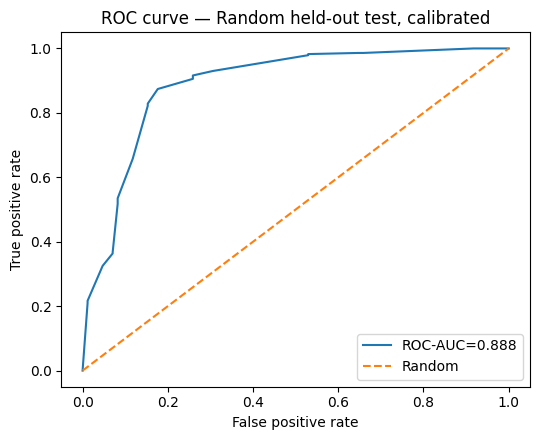

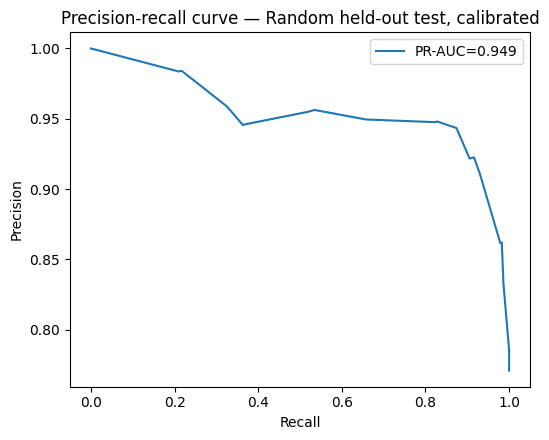

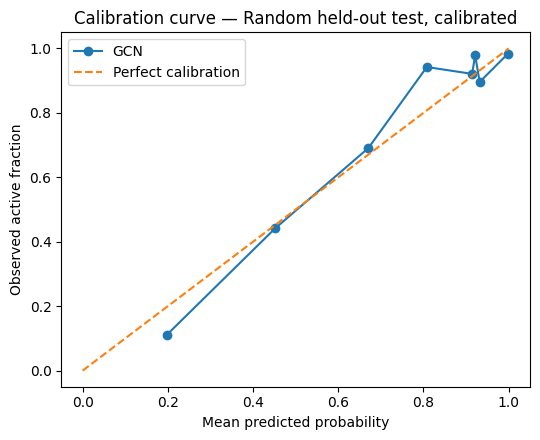

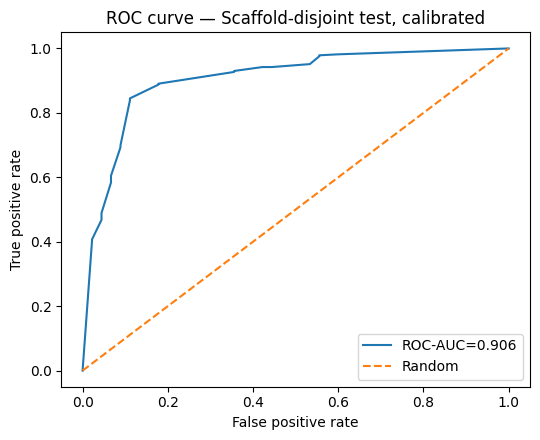

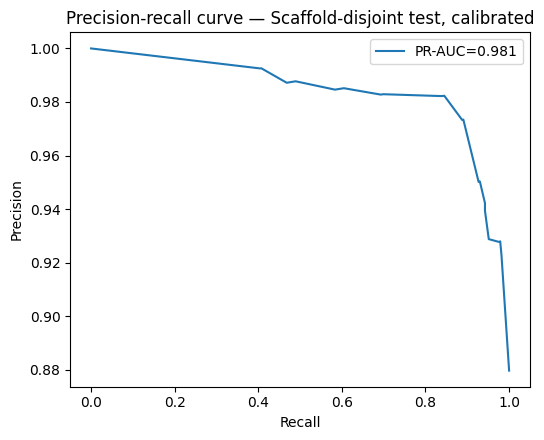

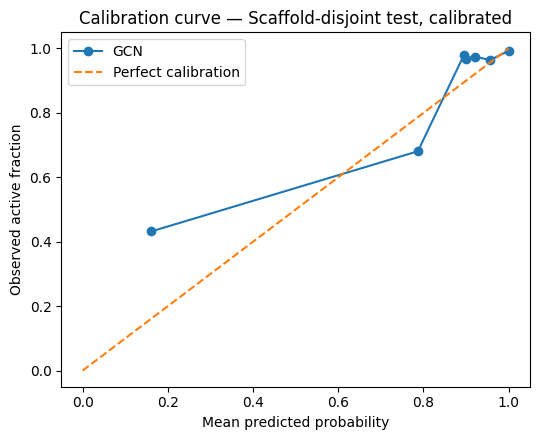

In [24]:
# ============================================================
# 11. Validation plots: ROC, PR, and calibration
# ============================================================

def save_roc_pr_calibration(y_true, prob, prefix, title):
    y_true = np.asarray(y_true).astype(int)
    prob = np.asarray(prob).astype(float)

    if len(np.unique(y_true)) < 2:
        print(f"Skipping validation plots for {title}: only one class in y_true.")
        return

    # ROC
    fpr, tpr, _ = roc_curve(y_true, prob)
    auc_val = roc_auc_score(y_true, prob)
    plt.figure(figsize=(5.5, 4.5))
    plt.plot(fpr, tpr, label=f"ROC-AUC={auc_val:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
    plt.xlabel("False positive rate")
    plt.ylabel("True positive rate")
    plt.title(f"ROC curve — {title}")
    plt.legend()
    plt.tight_layout()
    roc_path = os.path.join(FIG_DIR, f"{prefix}_roc_curve.png")
    plt.savefig(roc_path, dpi=300)
    plt.show()

    # PR
    precision, recall, _ = precision_recall_curve(y_true, prob)
    pr_val = average_precision_score(y_true, prob)
    plt.figure(figsize=(5.5, 4.5))
    plt.plot(recall, precision, label=f"PR-AUC={pr_val:.3f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision-recall curve — {title}")
    plt.legend()
    plt.tight_layout()
    pr_path = os.path.join(FIG_DIR, f"{prefix}_pr_curve.png")
    plt.savefig(pr_path, dpi=300)
    plt.show()

    # Calibration
    frac_pos, mean_pred = calibration_curve(y_true, prob, n_bins=min(10, max(2, len(y_true)//20)), strategy="quantile")
    plt.figure(figsize=(5.5, 4.5))
    plt.plot(mean_pred, frac_pos, marker="o", label="GCN")
    plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
    plt.xlabel("Mean predicted probability")
    plt.ylabel("Observed active fraction")
    plt.title(f"Calibration curve — {title}")
    plt.legend()
    plt.tight_layout()
    cal_path = os.path.join(FIG_DIR, f"{prefix}_calibration_curve.png")
    plt.savefig(cal_path, dpi=300)
    plt.show()

save_roc_pr_calibration(y_test_rand, rand_test_prob_cal, "gcn_random_heldout_test_calibrated", "Random held-out test, calibrated")
save_roc_pr_calibration(y_test_scaf, scaf_test_prob_cal, "gcn_scaffold_disjoint_test_calibrated", "Scaffold-disjoint test, calibrated")


## 12. Train final GCN ensemble for candidate screening

The final screening ensemble trains multiple GCNs with the selected configuration. The mean probability is used as GCN evidence, and the standard deviation is used as an uncertainty estimate. This is more defensible than a single neural network prediction because DeepChem graph models can be sensitive to initialization.


In [25]:
# For production screening, train on all curated compounds.
all_train_indices = np.arange(len(df_train))
production_models = []

for seed in ENSEMBLE_SEEDS:
    model_name = f"production_ensemble_seed_{seed}"
    print(f"\nTraining production GCN ensemble model: seed={seed}")
    m = train_gcn_model(all_train_indices, best_params, seed, model_name, GCN_EPOCHS_FINAL)
    production_models.append(m)

ensemble_summary = {
    "best_params": best_params,
    "ensemble_seeds": ENSEMBLE_SEEDS,
    "n_models": len(production_models),
    "epochs_final": GCN_EPOCHS_FINAL,
    "batch_size": GCN_BATCH_SIZE,
}
with open(os.path.join(DEEP_RUN_DIR, "gcn_production_ensemble_summary.json"), "w") as f:
    json.dump(ensemble_summary, f, indent=2)

print("Production ensemble training complete.")



Training production GCN ensemble model: seed=11

Training production GCN ensemble model: seed=42

Training production GCN ensemble model: seed=77
Production ensemble training complete.


## 13. Featurize candidate molecules and predict with the GCN ensemble

The production GCN ensemble is trained on the curated AURKB training set using independent random seeds. Predictions are generated in batches. The ensemble mean is calibrated using the validation-fitted isotonic mapping, while the ensemble standard deviation is retained as an uncertainty estimate.


In [26]:
# ============================================================
# 13. Candidate featurization and calibrated GCN ensemble prediction
# ============================================================

def predict_gcn_ensemble(smiles_list, batch_size=1000):
    all_raw_mean = []
    all_cal_mean = []
    all_std = []
    all_valid = []

    for start in tqdm(range(0, len(smiles_list), batch_size), desc="GCN screening batches"):
        batch_smiles = smiles_list[start:start + batch_size]
        graphs = featurizer.featurize(batch_smiles)
        graphs = np.asarray(graphs, dtype=object)
        valid = np.array([is_valid_graph_object(g) for g in graphs], dtype=bool)

        probs_models = []
        if valid.sum() > 0:
            ds = dc.data.NumpyDataset(X=graphs[valid])
            for model in production_models:
                probs_models.append(extract_positive_prob(model.predict(ds)))
            probs_models = np.vstack(probs_models)
            raw_mean_valid = probs_models.mean(axis=0)
            std_valid = probs_models.std(axis=0)
            cal_mean_valid = gcn_probability_calibrator.transform(raw_mean_valid)
        else:
            raw_mean_valid = np.array([])
            cal_mean_valid = np.array([])
            std_valid = np.array([])

        raw_mean_batch = np.full(len(batch_smiles), np.nan)
        cal_mean_batch = np.full(len(batch_smiles), np.nan)
        std_batch = np.full(len(batch_smiles), np.nan)

        raw_mean_batch[valid] = raw_mean_valid
        cal_mean_batch[valid] = cal_mean_valid
        std_batch[valid] = std_valid

        all_raw_mean.extend(raw_mean_batch.tolist())
        all_cal_mean.extend(cal_mean_batch.tolist())
        all_std.extend(std_batch.tolist())
        all_valid.extend(valid.tolist())

    return np.array(all_raw_mean), np.array(all_cal_mean), np.array(all_std), np.array(all_valid)

candidate_smiles = candidate_df["smiles"].tolist()
gcn_raw_mean, gcn_cal_mean, gcn_std, gcn_valid = predict_gcn_ensemble(candidate_smiles, batch_size=GCN_SCREENING_BATCH_SIZE)

candidate_df["prob_active_gcn_raw_mean"] = gcn_raw_mean
candidate_df["prob_active_gcn_calibrated"] = gcn_cal_mean
candidate_df["prob_active_gcn_std"] = gcn_std
candidate_df["gcn_featurization_valid"] = gcn_valid

n_before = len(candidate_df)
candidate_df = candidate_df[candidate_df["gcn_featurization_valid"]].reset_index(drop=True)
print(f"GCN predictions generated for {len(candidate_df):,}/{n_before:,} candidates.")

print(candidate_df[[
    "smiles", "prob_active_qsar", "prob_active_gcn_raw_mean",
    "prob_active_gcn_calibrated", "prob_active_gcn_std"
]].head())


GCN screening batches:   0%|          | 0/7 [00:00<?, ?it/s]

GCN predictions generated for 6,232/6,232 candidates.
                                              smiles  prob_active_qsar  \
0  O=C(Cn1nc(Cl)ccc1=O)Nc1ccc(C(=O)NC[C@@H]2CCCN3...          0.945540   
1   O=C(CCc1nc2cc(Br)cnc2[nH]1)NC[C@@H]1CCCN2CCCCC12          0.945272   
2  NC(=O)Cc1csc(NC(=O)CCCN2C(=O)c3ccccc3N3C(=O)c4...          0.944537   
3  O=C(Cn1cnc2c(N3CCCCC3)nc(Cl)nc21)NC[C@@H]1CCCN...          0.943971   
4  O=C(N[C@H]1CCN2C(=O)c3cc(/C=C/c4ccccc4)ccc3NC(...          0.943900   

   prob_active_gcn_raw_mean  prob_active_gcn_calibrated  prob_active_gcn_std  
0                  0.353860                    0.808511             0.136845  
1                  0.430445                    0.914286             0.097629  
2                  0.905514                    1.000000             0.049133  
3                  0.323686                    0.808511             0.060898  
4                  0.523395                    0.914286             0.192498  


## 14. Structural support / graph-domain proxy using Morgan nearest-neighbour similarity

This is not a replacement for an experimental applicability domain, but it helps identify candidates that are very far from the curated AURKB chemical space. Candidates with low nearest-neighbour similarity can still be novel, but should be interpreted more cautiously.


In [27]:
def mol_from_smiles_safe(smi):
    try:
        return Chem.MolFromSmiles(str(smi))
    except Exception:
        return None

def morgan_fp(smi, radius=2, n_bits=2048):
    mol = mol_from_smiles_safe(smi)
    if mol is None:
        return None
    return AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits)

train_fps = [morgan_fp(s) for s in df_train["smiles_gcn"].tolist()]
train_y = df_train["y"].astype(int).values
active_fps = [fp for fp, y in zip(train_fps, train_y) if fp is not None and y == 1]
all_train_fps = [fp for fp in train_fps if fp is not None]

candidate_fps = [morgan_fp(s) for s in tqdm(candidate_df["smiles"].tolist(), desc="Morgan fingerprints")]

max_train_sim = []
max_active_sim = []
for fp in tqdm(candidate_fps, desc="Nearest-neighbour similarity"):
    if fp is None:
        max_train_sim.append(np.nan)
        max_active_sim.append(np.nan)
    else:
        sims_train = DataStructs.BulkTanimotoSimilarity(fp, all_train_fps) if all_train_fps else [np.nan]
        sims_active = DataStructs.BulkTanimotoSimilarity(fp, active_fps) if active_fps else [np.nan]
        max_train_sim.append(float(np.nanmax(sims_train)))
        max_active_sim.append(float(np.nanmax(sims_active)))

candidate_df["max_tanimoto_to_training"] = max_train_sim
candidate_df["max_tanimoto_to_training_active"] = max_active_sim
candidate_df["structural_support"] = candidate_df["max_tanimoto_to_training"] >= MIN_TRAIN_SIMILARITY

candidate_df[["smiles", "max_tanimoto_to_training", "max_tanimoto_to_training_active", "structural_support"]].head()


Morgan fingerprints:   0%|          | 0/6232 [00:00<?, ?it/s]

Nearest-neighbour similarity:   0%|          | 0/6232 [00:00<?, ?it/s]

,smiles,max_tanimoto_to_training,max_tanimoto_to_training_active,structural_support
0,O=C(Cn1nc(Cl)ccc1=O)Nc1ccc(C(=O)NC[C@@H]2CCCN3...,0.260870,0.260870,False
1,O=C(CCc1nc2cc(Br)cnc2[nH]1)NC[C@@H]1CCCN2CCCCC12,0.257732,0.257732,False
2,NC(=O)Cc1csc(NC(=O)CCCN2C(=O)c3ccccc3N3C(=O)c4...,0.241379,0.241379,False
3,O=C(Cn1cnc2c(N3CCCCC3)nc(Cl)nc21)NC[C@@H]1CCCN...,0.231579,0.231579,False
4,O=C(N[C@H]1CCN2C(=O)c3cc(/C=C/c4ccccc4)ccc3NC(...,0.285714,0.285714,False


## 15. Drug-likeness and structural-alert annotation

These annotations are used for prioritization, not as absolute exclusion rules. Natural products can violate classical oral drug-likeness filters while remaining biologically relevant; therefore, violations are reported transparently.


In [28]:
# Build RDKit structural-alert catalog once.
params = FilterCatalog.FilterCatalogParams()
params.AddCatalog(FilterCatalog.FilterCatalogParams.FilterCatalogs.PAINS)
params.AddCatalog(FilterCatalog.FilterCatalogParams.FilterCatalogs.BRENK)
alert_catalog = FilterCatalog.FilterCatalog(params)

def compute_basic_admet(smi):
    mol = mol_from_smiles_safe(smi)
    if mol is None:
        return {}
    mw = Descriptors.MolWt(mol)
    logp = Descriptors.MolLogP(mol)
    hbd = rdMolDescriptors.CalcNumHBD(mol)
    hba = rdMolDescriptors.CalcNumHBA(mol)
    tpsa = Descriptors.TPSA(mol)
    rotb = rdMolDescriptors.CalcNumRotatableBonds(mol)
    qed_val = QED.qed(mol)
    fsp3 = rdMolDescriptors.CalcFractionCSP3(mol)
    arom_rings = rdMolDescriptors.CalcNumAromaticRings(mol)
    heavy_atoms = mol.GetNumHeavyAtoms()
    ro5_viol = int(mw > 500) + int(logp > 5) + int(hbd > 5) + int(hba > 10)
    veber_ok = (tpsa <= 140) and (rotb <= 10)
    alerts = alert_catalog.GetMatches(mol)
    alert_descriptions = [a.GetDescription() for a in alerts]
    pains_or_brenk = len(alerts) > 0
    return {
        "MW": round(mw, 3),
        "LogP": round(logp, 3),
        "HBD": int(hbd),
        "HBA": int(hba),
        "TPSA": round(tpsa, 3),
        "RotBonds": int(rotb),
        "QED": round(qed_val, 4),
        "Fsp3": round(fsp3, 4),
        "AromaticRings": int(arom_rings),
        "HeavyAtoms": int(heavy_atoms),
        "Ro5_violations": int(ro5_viol),
        "Veber_OK": bool(veber_ok),
        "structural_alert": bool(pains_or_brenk),
        "structural_alert_descriptions": "; ".join(alert_descriptions[:5]),
    }

admet_df = pd.DataFrame([compute_basic_admet(s) for s in tqdm(candidate_df["smiles"], desc="ADMET annotations")])
candidate_df = pd.concat([candidate_df.reset_index(drop=True), admet_df.reset_index(drop=True)], axis=1)

print(candidate_df[["smiles", "MW", "LogP", "TPSA", "QED", "Ro5_violations", "Veber_OK", "structural_alert"]].head())


ADMET annotations:   0%|          | 0/6232 [00:00<?, ?it/s]

                                              smiles       MW   LogP    TPSA  \
0  O=C(Cn1nc(Cl)ccc1=O)Nc1ccc(C(=O)NC[C@@H]2CCCN3...  457.962  2.530   96.33   
1   O=C(CCc1nc2cc(Br)cnc2[nH]1)NC[C@@H]1CCCN2CCCCC12  420.355  3.034   73.91   
2  NC(=O)Cc1csc(NC(=O)CCCN2C(=O)c3ccccc3N3C(=O)c4...  475.530  2.705  125.70   
3  O=C(Cn1cnc2c(N3CCCCC3)nc(Cl)nc21)NC[C@@H]1CCCN...  445.999  2.851   79.18   
4  O=C(N[C@H]1CCN2C(=O)c3cc(/C=C/c4ccccc4)ccc3NC(...  439.475  2.612  104.29   

      QED  Ro5_violations  Veber_OK  structural_alert  
0  0.6944               0      True             False  
1  0.7801               0      True             False  
2  0.5435               0      True             False  
3  0.7127               0      True             False  
4  0.6084               0      True              True  


## 16. Uncertainty-aware consensus scoring and tier assignment

The primary consensus score is rank-normalized to avoid overinterpreting raw probability scales from different models. Higher scores are better.

```text
consensus_rank_score = 0.45 × QSAR percentile + 0.45 × GCN percentile + 0.10 × uncertainty-confidence percentile
```

A transparent arithmetic score is also saved for comparison:

```text
consensus_mean_probability = mean(QSAR probability, GCN ensemble mean)
```


In [29]:
# ============================================================
# 16. Uncertainty-aware calibrated QSAR–GCN consensus scoring
# ============================================================

if len(candidate_df) == 0:
    raise ValueError("No valid GCN-featurized candidates remain. Check screening input and SMILES standardization.")

def percentile_rank_high_better(series):
    return series.rank(method="average", pct=True)

def percentile_rank_low_better(series):
    return 1.0 - series.rank(method="average", pct=True) + (1.0 / len(series))

candidate_df["qsar_rank_pct"] = percentile_rank_high_better(candidate_df["prob_active_qsar"])
candidate_df["gcn_rank_pct"] = percentile_rank_high_better(candidate_df["prob_active_gcn_calibrated"])
candidate_df["uncertainty_rank_pct"] = percentile_rank_low_better(candidate_df["prob_active_gcn_std"].fillna(1.0))

candidate_df["consensus_mean_probability"] = candidate_df[["prob_active_qsar", "prob_active_gcn_calibrated"]].mean(axis=1)
candidate_df["consensus_rank_score"] = (
    0.45 * candidate_df["qsar_rank_pct"] +
    0.45 * candidate_df["gcn_rank_pct"] +
    0.10 * candidate_df["uncertainty_rank_pct"]
)

candidate_df["qsar_pass"] = (candidate_df["prob_active_qsar"] >= QSAR_HIGH_CONF_THRESHOLD) & (candidate_df["inside_AD"].astype(bool))
candidate_df["gcn_pass"] = candidate_df["prob_active_gcn_calibrated"] >= GCN_PROB_THRESHOLD
candidate_df["uncertainty_pass"] = candidate_df["prob_active_gcn_std"] <= GCN_UNCERTAINTY_MAX_STD
candidate_df["support_pass"] = candidate_df["max_tanimoto_to_training"] >= MIN_TRAIN_SIMILARITY
candidate_df["alert_pass"] = ~candidate_df["structural_alert"].astype(bool)
candidate_df["druglike_soft_pass"] = (candidate_df["Ro5_violations"] <= 1) & (candidate_df["Veber_OK"].astype(bool))

# Tiering: this should be reported as in-silico prioritization, not experimental confirmation.
conditions_tier1 = (
    candidate_df["qsar_pass"] &
    candidate_df["gcn_pass"] &
    candidate_df["uncertainty_pass"] &
    candidate_df["support_pass"] &
    candidate_df["alert_pass"] &
    candidate_df["druglike_soft_pass"]
)
conditions_tier2 = (
    candidate_df["qsar_pass"] &
    candidate_df["gcn_pass"] &
    candidate_df["uncertainty_pass"] &
    (candidate_df["alert_pass"] | candidate_df["druglike_soft_pass"])
)
conditions_tier3 = candidate_df["qsar_pass"] & candidate_df["gcn_pass"]

candidate_df["consensus_tier"] = "Tier_4_lower_priority"
candidate_df.loc[conditions_tier3, "consensus_tier"] = "Tier_3_model_agreement"
candidate_df.loc[conditions_tier2, "consensus_tier"] = "Tier_2_model_agreement_low_uncertainty"
candidate_df.loc[conditions_tier1, "consensus_tier"] = "Tier_1_high_confidence"

tier_order = {
    "Tier_1_high_confidence": 1,
    "Tier_2_model_agreement_low_uncertainty": 2,
    "Tier_3_model_agreement": 3,
    "Tier_4_lower_priority": 4,
}
candidate_df["tier_order"] = candidate_df["consensus_tier"].map(tier_order)

candidate_df = candidate_df.sort_values(
    ["tier_order", "consensus_rank_score", "consensus_mean_probability"],
    ascending=[True, False, False]
).reset_index(drop=True)

# Save all consensus results and top lead files.
all_consensus_path = os.path.join(TABLE_DIR, "AURKB_GCN_QSAR_consensus_all_candidates.csv")
tier1_path = os.path.join(TABLE_DIR, "AURKB_GCN_QSAR_consensus_Tier1_high_confidence.csv")
top100_path = os.path.join(TABLE_DIR, f"AURKB_GCN_QSAR_consensus_top{TOP_N_EXPORT}.csv")

candidate_df.to_csv(all_consensus_path, index=False)
candidate_df[candidate_df["consensus_tier"] == "Tier_1_high_confidence"].to_csv(tier1_path, index=False)
candidate_df.head(TOP_N_EXPORT).to_csv(top100_path, index=False)

summary = {
    "n_candidates_scored": int(len(candidate_df)),
    "tier_counts": candidate_df["consensus_tier"].value_counts().to_dict(),
    "qsar_pass": int(candidate_df["qsar_pass"].sum()),
    "gcn_pass_calibrated": int(candidate_df["gcn_pass"].sum()),
    "uncertainty_pass": int(candidate_df["uncertainty_pass"].sum()),
    "support_pass": int(candidate_df["support_pass"].sum()),
    "alert_pass": int(candidate_df["alert_pass"].sum()),
    "druglike_soft_pass": int(candidate_df["druglike_soft_pass"].sum()),
    "consensus_score_formula": "0.45*QSAR_rank_pct + 0.45*calibrated_GCN_rank_pct + 0.10*low_uncertainty_rank_pct",
}
with open(os.path.join(DEEP_RUN_DIR, "consensus_screening_summary.json"), "w") as f:
    json.dump(summary, f, indent=2)

print(json.dumps(summary, indent=2))
print("\nSaved:")
print(all_consensus_path)
print(tier1_path)
print(top100_path)

display(candidate_df.head(10)[[
    "smiles", "prob_active_qsar", "prob_active_gcn_calibrated", "prob_active_gcn_std",
    "max_tanimoto_to_training", "QED", "Ro5_violations", "structural_alert",
    "consensus_rank_score", "consensus_tier"
]])


{
  "n_candidates_scored": 6232,
  "tier_counts": {
    "Tier_2_model_agreement_low_uncertainty": 3742,
    "Tier_4_lower_priority": 939,
    "Tier_3_model_agreement": 936,
    "Tier_1_high_confidence": 615
  },
  "qsar_pass": 6232,
  "gcn_pass_calibrated": 5293,
  "uncertainty_pass": 5296,
  "support_pass": 1006,
  "alert_pass": 5232,
  "druglike_soft_pass": 6232,
  "consensus_score_formula": "0.45*QSAR_rank_pct + 0.45*calibrated_GCN_rank_pct + 0.10*low_uncertainty_rank_pct"
}

Saved:
/content/drive/MyDrive/AURKB_QSAR_Publication_Ready/02_QSAR_ML_20260520_045612/03_DeepChem_GCN_Consensus_20260521_074502/tables/AURKB_GCN_QSAR_consensus_all_candidates.csv
/content/drive/MyDrive/AURKB_QSAR_Publication_Ready/02_QSAR_ML_20260520_045612/03_DeepChem_GCN_Consensus_20260521_074502/tables/AURKB_GCN_QSAR_consensus_Tier1_high_confidence.csv
/content/drive/MyDrive/AURKB_QSAR_Publication_Ready/02_QSAR_ML_20260520_045612/03_DeepChem_GCN_Consensus_20260521_074502/tables/AURKB_GCN_QSAR_consensus_top10

,smiles,prob_active_qsar,prob_active_gcn_calibrated,prob_active_gcn_std,max_tanimoto_to_training,QED,Ro5_violations,structural_alert,consensus_rank_score,consensus_tier
0,O=C(Nc1c[nH]nc1-c1nc2ccc(CN3CCOCC3)cc2[nH]1)NC...,0.940819,1.000000,0.016691,1.000000,0.5407,0,False,0.987881,Tier_1_high_confidence
1,O=C(Nc1ccc2n(c1=O)C[C@H]1C[C@@H]2CN(S(=O)(=O)c...,0.937362,1.000000,0.012510,0.301205,0.5441,1,False,0.986293,Tier_1_high_confidence
2,NC(=O)c1ccc(Nc2nc(OCC3CCCCC3)c3nc[nH]c3n2)cc1,0.926476,1.000000,0.018805,0.754098,0.6164,0,False,0.962151,Tier_1_high_confidence
3,O=C(NC1CCCCC1)N[C@H]1CCN2C(=O)c3ccccc3NC(=O)[C...,0.926467,1.000000,0.030215,0.302632,0.7553,0,False,0.955355,Tier_1_high_confidence
4,Cn1cc(NC(=O)CN2C(=O)[C@@H]3CCCN3C(=O)c3ccccc32...,0.924534,1.000000,0.033997,0.317647,0.8921,0,False,0.947405,Tier_1_high_confidence
5,Cc1ccc(-c2noc([C@@H]3C[C@H](NC(=O)NC4CCCCC4)CN...,0.918738,1.000000,0.021178,0.320988,0.8452,0,False,0.940328,Tier_1_high_confidence
6,CSCC[C@@H]1NC(=O)c2cc(NC(=O)c3cccc4c3ccn4C)ccc...,0.928906,0.928571,0.029207,0.341176,0.5886,0,False,0.931025,Tier_1_high_confidence
7,O=C(Cn1cc(Br)cn1)Nc1ccc(C(=O)NC[C@@H]2CCCN3CCC...,0.942363,0.928571,0.063712,0.301205,0.6739,0,False,0.925289,Tier_1_high_confidence
8,O=C(Nc1cccc(S(=O)(=O)N2CCN(c3ccccn3)CC2)c1)Nc1...,0.922827,1.000000,0.068423,0.311828,0.6266,0,False,0.918561,Tier_1_high_confidence
9,O=C(NCc1noc([C@@H]2CCC(=O)N2CC2CC2)n1)Nc1ccccc1,0.917967,0.933333,0.029440,0.320513,0.8289,0,False,0.918096,Tier_1_high_confidence


## 17. Consensus visualizations


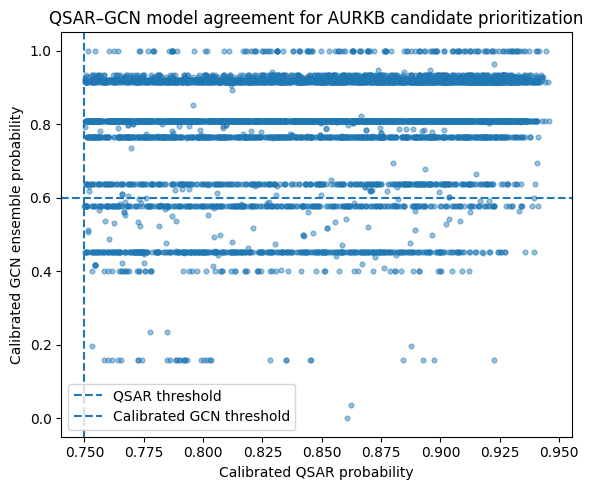

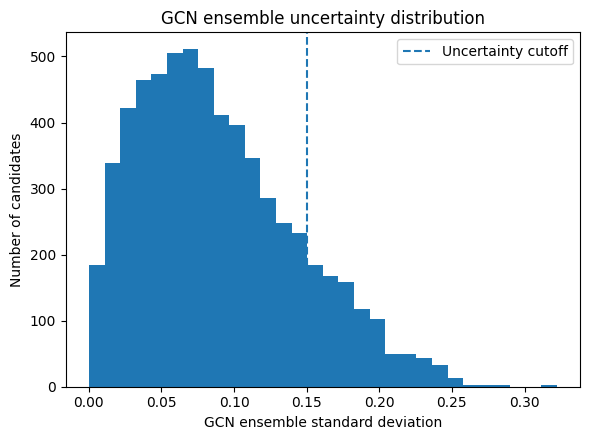

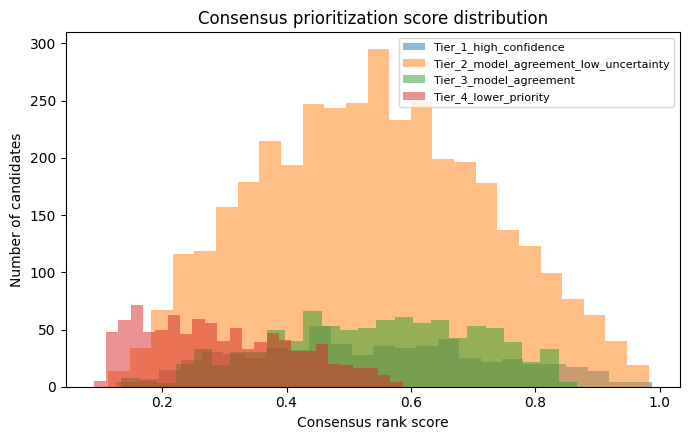

In [30]:
# ============================================================
# 17. Consensus visualizations
# ============================================================

# Model agreement scatter
plt.figure(figsize=(6, 5))
plt.scatter(candidate_df["prob_active_qsar"], candidate_df["prob_active_gcn_calibrated"], s=12, alpha=0.45)
plt.axvline(QSAR_HIGH_CONF_THRESHOLD, linestyle="--", label="QSAR threshold")
plt.axhline(GCN_PROB_THRESHOLD, linestyle="--", label="Calibrated GCN threshold")
plt.xlabel("Calibrated QSAR probability")
plt.ylabel("Calibrated GCN ensemble probability")
plt.title("QSAR–GCN model agreement for AURKB candidate prioritization")
plt.legend()
plt.tight_layout()
agreement_path = os.path.join(FIG_DIR, "QSAR_GCN_model_agreement_scatter_calibrated.png")
plt.savefig(agreement_path, dpi=300)
plt.show()

# Uncertainty distribution
plt.figure(figsize=(6, 4.5))
plt.hist(candidate_df["prob_active_gcn_std"].dropna(), bins=30)
plt.axvline(GCN_UNCERTAINTY_MAX_STD, linestyle="--", label="Uncertainty cutoff")
plt.xlabel("GCN ensemble standard deviation")
plt.ylabel("Number of candidates")
plt.title("GCN ensemble uncertainty distribution")
plt.legend()
plt.tight_layout()
unc_path = os.path.join(FIG_DIR, "GCN_ensemble_uncertainty_distribution.png")
plt.savefig(unc_path, dpi=300)
plt.show()

# Consensus score distribution by tier
plt.figure(figsize=(7, 4.5))
for tier, sub in candidate_df.groupby("consensus_tier"):
    plt.hist(sub["consensus_rank_score"], bins=25, alpha=0.5, label=tier)
plt.xlabel("Consensus rank score")
plt.ylabel("Number of candidates")
plt.title("Consensus prioritization score distribution")
plt.legend(fontsize=8)
plt.tight_layout()
score_path = os.path.join(FIG_DIR, "Consensus_score_distribution_by_tier.png")
plt.savefig(score_path, dpi=300)
plt.show()


## 18. Scaffold enrichment among prioritized leads

This table helps reviewers see whether top candidates are dominated by one scaffold or distributed across chemical series.


In [31]:
# ============================================================
# 18. Scaffold enrichment among prioritized leads
# ============================================================

candidate_df["murcko_scaffold"] = candidate_df["smiles"].apply(murcko_scaffold_smiles)
candidate_df.loc[candidate_df["murcko_scaffold"] == "", "murcko_scaffold"] = "acyclic_or_no_scaffold"

top_for_scaffold = candidate_df.head(TOP_N_EXPORT).copy()
scaffold_summary = (
    top_for_scaffold.groupby("murcko_scaffold")
    .agg(
        n_candidates=("smiles", "count"),
        mean_consensus_score=("consensus_rank_score", "mean"),
        max_consensus_score=("consensus_rank_score", "max"),
        mean_qsar=("prob_active_qsar", "mean"),
        mean_gcn_calibrated=("prob_active_gcn_calibrated", "mean"),
        mean_uncertainty=("prob_active_gcn_std", "mean"),
    )
    .sort_values(["n_candidates", "max_consensus_score"], ascending=False)
    .reset_index()
)
scaffold_path = os.path.join(TABLE_DIR, f"top{TOP_N_EXPORT}_scaffold_summary.csv")
scaffold_summary.to_csv(scaffold_path, index=False)
display(scaffold_summary.head(15))


,murcko_scaffold,n_candidates,mean_consensus_score,max_consensus_score,mean_qsar,mean_gcn_calibrated,mean_uncertainty
0,O=C(Nc1ncccn1)NS(=O)(=O)c1cccs1,4,0.905662,0.914036,0.910019,1.000000,0.038412
1,O=C(Nc1ccccc1)N[C@H]1CO[C@H]2[C@@H]1OC[C@@H]2N...,3,0.791914,0.824190,0.900441,0.926237,0.101740
2,O=C(NC1CCCCC1)N[C@@H]1CN[C@H](c2nc(-c3ccccc3)n...,2,0.920712,0.940328,0.914881,0.966667,0.024049
3,O=C(NC[C@@H]1CCCN2CCCC[C@H]12)c1ccc(Nc2ncccn2)cc1,2,0.840402,0.894608,0.933067,0.917927,0.072419
4,O=C1CC[C@@H](c2nc(CNC(=O)Nc3ccccc3)no2)N1,2,0.869009,0.880179,0.900994,0.964286,0.033599
5,O=C(Nc1ccccc1)Nc1ccc2n(c1=O)C[C@H]1C[C@@H]2CN(...,2,0.866736,0.877519,0.918734,0.921569,0.030549
6,O=C(CC1NC(=O)c2ccccc2NC1=O)Nc1ccc2nc[nH]c(=O)c2c1,2,0.811708,0.862733,0.919529,0.921429,0.090626
7,O=C(N[C@H]1CCN2C(=O)c3ccccc3NC(=O)[C@H]12)c1cc...,2,0.811196,0.829008,0.914454,0.925070,0.128634
8,O=C(N[C@@H]1CCN2C(=O)c3ccccc3NC(=O)[C@H]12)c1c...,2,0.811196,0.828991,0.914454,0.925070,0.128634
9,O=C(Nc1ccccc1)N[C@@H]1CN[C@H](c2nc(-c3ccccc3)n...,2,0.801982,0.821073,0.880937,0.933333,0.052700


**Block 18A — Bootstrap 95% confidence intervals for model metrics**

This adds statistical confidence around your validation metrics.

In [35]:
# ============================================================
# 18A. Bootstrap 95% confidence intervals for GCN validation metrics
# ============================================================

import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, average_precision_score, balanced_accuracy_score, matthews_corrcoef

def bootstrap_metric_ci(y_true, prob, threshold=0.5, n_boot=1000, seed=SEED):
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true).astype(int)
    prob = np.asarray(prob).astype(float)
    pred = (prob >= threshold).astype(int)
    n = len(y_true)

    rows = []
    for _ in range(n_boot):
        idx = rng.choice(np.arange(n), size=n, replace=True)
        yb = y_true[idx]
        pb = prob[idx]
        pr = (pb >= threshold).astype(int)

        if len(np.unique(yb)) < 2:
            continue

        rows.append({
            "roc_auc": roc_auc_score(yb, pb),
            "pr_auc": average_precision_score(yb, pb),
            "balanced_accuracy": balanced_accuracy_score(yb, pr),
            "mcc": matthews_corrcoef(yb, pr) if len(np.unique(pr)) > 1 else 0.0
        })

    boot_df = pd.DataFrame(rows)

    summary = []
    for col in boot_df.columns:
        summary.append({
            "metric": col,
            "mean": boot_df[col].mean(),
            "ci_lower_2.5": boot_df[col].quantile(0.025),
            "ci_upper_97.5": boot_df[col].quantile(0.975),
        })

    return pd.DataFrame(summary)

# Use variables already generated in Block 9
ci_random_cal = bootstrap_metric_ci(
    y_test_rand,
    rand_test_prob_cal,
    threshold=best_threshold_cal,
    n_boot=1000,
    seed=SEED
)
ci_random_cal["evaluation"] = "GCN_random_test_calibrated"

ci_scaffold_cal = bootstrap_metric_ci(
    y_test_scaf,
    scaf_test_prob_cal,
    threshold=scaf_threshold_cal,
    n_boot=1000,
    seed=SEED
)
ci_scaffold_cal["evaluation"] = "GCN_scaffold_test_calibrated"

ci_df = pd.concat([ci_random_cal, ci_scaffold_cal], ignore_index=True)

ci_path = os.path.join(TABLE_DIR, "gcn_validation_bootstrap_95CI.csv")
ci_df.to_csv(ci_path, index=False)

print(ci_df)
print("Saved:", ci_path)

              metric      mean  ci_lower_2.5  ci_upper_97.5  \
0            roc_auc  0.886715      0.838122       0.929543   
1             pr_auc  0.948584      0.920012       0.972277   
2  balanced_accuracy  0.847256      0.799618       0.892251   
3                mcc  0.644915      0.551738       0.734295   
4            roc_auc  0.906738      0.852570       0.949646   
5             pr_auc  0.981108      0.965933       0.991975   
6  balanced_accuracy  0.749965      0.676461       0.824566   
7                mcc  0.503646      0.365746       0.633602   

                     evaluation  
0    GCN_random_test_calibrated  
1    GCN_random_test_calibrated  
2    GCN_random_test_calibrated  
3    GCN_random_test_calibrated  
4  GCN_scaffold_test_calibrated  
5  GCN_scaffold_test_calibrated  
6  GCN_scaffold_test_calibrated  
7  GCN_scaffold_test_calibrated  
Saved: /content/drive/MyDrive/AURKB_QSAR_Publication_Ready/02_QSAR_ML_20260520_045612/03_DeepChem_GCN_Consensus_20260521_07450

**Block 18B — Y-randomization / label permutation test**

This is very important. It proves your model is learning chemical signal, not accidental patterns.

For speed, first run Y-randomization using ECFP Random Forest. This is acceptable as a sanity control.

In [37]:
# ============================================================
# 18B. Y-randomization / label permutation control using ECFP-RF
# ============================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, matthews_corrcoef, balanced_accuracy_score
from sklearn.utils import shuffle
import numpy as np
import pandas as pd
import os

N_PERMUTATIONS = 30

# Reuse ECFP feature matrix if already available.
# If your notebook used another name, replace X_ecfp with the correct variable.
print("Available ECFP variable check:")
for name in ["X_ecfp", "X_fp", "fp_matrix"]:
    print(name, name in globals())

if "X_ecfp" in globals():
    X_perm = X_ecfp
elif "X_fp" in globals():
    X_perm = X_fp
elif "fp_matrix" in globals():
    X_perm = fp_matrix
else:
    raise NameError("Could not find ECFP matrix variable. Check your baseline block variable name.")

y_original = df_train["y"].astype(int).values

perm_rows = []

for i in range(N_PERMUTATIONS):
    rng_seed = SEED + i
    y_perm = shuffle(y_original, random_state=rng_seed)

    rf_perm = RandomForestClassifier(
        n_estimators=300,
        random_state=rng_seed,
        class_weight="balanced",
        n_jobs=-1
    )

    rf_perm.fit(X_perm[idx_train_scaf], y_perm[idx_train_scaf])
    prob_perm = rf_perm.predict_proba(X_perm[idx_test_scaf])[:, 1]
    pred_perm = (prob_perm >= 0.5).astype(int)

    y_test_perm = y_perm[idx_test_scaf]

    if len(np.unique(y_test_perm)) < 2:
        continue

    perm_rows.append({
        "permutation": i + 1,
        "roc_auc": roc_auc_score(y_test_perm, prob_perm),
        "pr_auc": average_precision_score(y_test_perm, prob_perm),
        "balanced_accuracy": balanced_accuracy_score(y_test_perm, pred_perm),
        "mcc": matthews_corrcoef(y_test_perm, pred_perm) if len(np.unique(pred_perm)) > 1 else 0.0
    })

perm_df = pd.DataFrame(perm_rows)
perm_path = os.path.join(TABLE_DIR, "y_randomization_ecfp_rf_scaffold_test.csv")
perm_df.to_csv(perm_path, index=False)

print(perm_df.describe())
print("Saved:", perm_path)

Available ECFP variable check:
X_ecfp False
X_fp True
fp_matrix False
       permutation    roc_auc     pr_auc  balanced_accuracy        mcc
count    30.000000  30.000000  30.000000          30.000000  30.000000
mean     15.500000   0.492113   0.768935           0.498862  -0.000270
std       8.803408   0.030380   0.018184           0.010276   0.055011
min       1.000000   0.409936   0.732999           0.467675  -0.101638
25%       8.250000   0.475601   0.758184           0.492325  -0.045652
50%      15.500000   0.491615   0.770254           0.498870  -0.006286
75%      22.750000   0.508694   0.782404           0.506126   0.044558
max      30.000000   0.545862   0.805950           0.516037   0.120597
Saved: /content/drive/MyDrive/AURKB_QSAR_Publication_Ready/02_QSAR_ML_20260520_045612/03_DeepChem_GCN_Consensus_20260521_074502/tables/y_randomization_ecfp_rf_scaffold_test.csv


**Block 18C — Calibration curve / reliability plot**

This supports your calibrated probability claims.

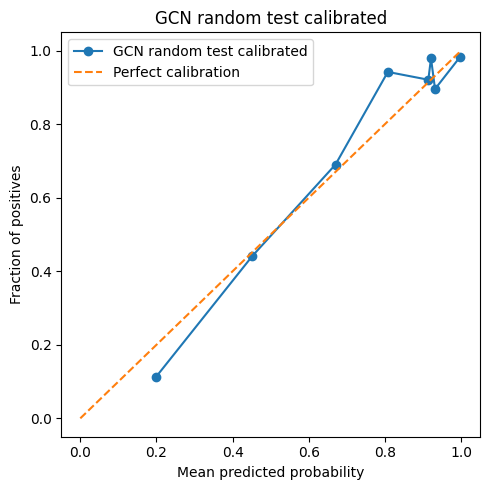

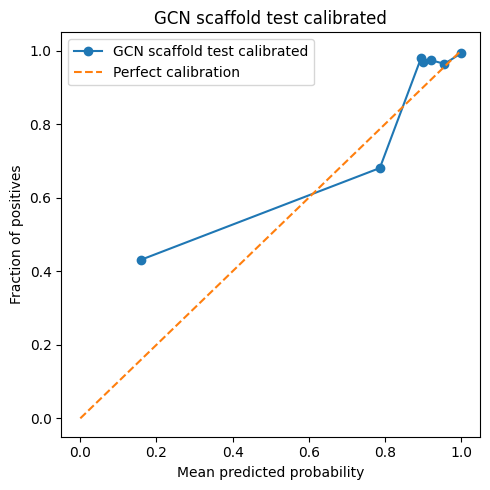

Calibration curves saved to: /content/drive/MyDrive/AURKB_QSAR_Publication_Ready/02_QSAR_ML_20260520_045612/03_DeepChem_GCN_Consensus_20260521_074502/figures


In [38]:
# ============================================================
# 18C. Calibration reliability curves
# ============================================================

import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

def plot_calibration_curve(y_true, prob, label, save_path):
    frac_pos, mean_pred = calibration_curve(y_true, prob, n_bins=10, strategy="quantile")

    plt.figure(figsize=(5, 5))
    plt.plot(mean_pred, frac_pos, marker="o", label=label)
    plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
    plt.xlabel("Mean predicted probability")
    plt.ylabel("Fraction of positives")
    plt.title(label)
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.show()

plot_calibration_curve(
    y_test_rand,
    rand_test_prob_cal,
    "GCN random test calibrated",
    os.path.join(FIG_DIR, "calibration_curve_random_test_calibrated.png")
)

plot_calibration_curve(
    y_test_scaf,
    scaf_test_prob_cal,
    "GCN scaffold test calibrated",
    os.path.join(FIG_DIR, "calibration_curve_scaffold_test_calibrated.png")
)

print("Calibration curves saved to:", FIG_DIR)

**Block 18D — Stricter elite lead selection**

This is very important because 615 Tier-1 compounds is too many.

In [41]:
# ============================================================
# 18D. Define stricter Tier 1A elite lead subset
# Corrected for this notebook: final consensus dataframe = candidate_df
# ============================================================

import numpy as np
import pandas as pd
import os

if "candidate_df" not in globals():
    raise NameError(
        "candidate_df is not defined. Run the notebook's consensus scoring block first: "
        "# 16. Uncertainty-aware calibrated QSAR–GCN consensus scoring"
    )

required_cols = [
    "smiles",
    "prob_active_qsar",
    "prob_active_gcn_calibrated",
    "prob_active_gcn_std",
    "max_tanimoto_to_training",
    "QED",
    "Ro5_violations",
    "structural_alert",
    "consensus_rank_score"
]

missing_cols = [c for c in required_cols if c not in candidate_df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns in candidate_df: {missing_cols}")

elite = candidate_df.copy()

elite = elite[
    (elite["prob_active_qsar"] >= 0.90) &
    (elite["prob_active_gcn_calibrated"] >= 0.80) &
    (elite["prob_active_gcn_std"] <= 0.05) &
    (elite["max_tanimoto_to_training"] >= 0.30) &
    (elite["max_tanimoto_to_training"] < 0.95) &
    (elite["structural_alert"] == False) &
    (elite["Ro5_violations"] <= 1)
].copy()

elite = elite.sort_values("consensus_rank_score", ascending=False).reset_index(drop=True)
elite["elite_rank"] = np.arange(1, len(elite) + 1)

elite_top50 = elite.head(50).copy()

elite_path = os.path.join(TABLE_DIR, "AURKB_consensus_Tier1A_elite_leads_top50.csv")
elite_top50.to_csv(elite_path, index=False)

print("Elite Tier 1A candidates:", len(elite))
print("Exported top:", len(elite_top50))

display_cols = [
    "elite_rank",
    "smiles",
    "prob_active_qsar",
    "prob_active_gcn_calibrated",
    "prob_active_gcn_std",
    "max_tanimoto_to_training",
    "QED",
    "Ro5_violations",
    "structural_alert",
    "consensus_rank_score"
]

display(elite_top50[display_cols].head(20))

print("Saved:", elite_path)

Elite Tier 1A candidates: 29
Exported top: 29


,elite_rank,smiles,prob_active_qsar,prob_active_gcn_calibrated,prob_active_gcn_std,max_tanimoto_to_training,QED,Ro5_violations,structural_alert,consensus_rank_score
0,1,O=C(Nc1ccc2n(c1=O)C[C@H]1C[C@@H]2CN(S(=O)(=O)c...,0.937362,1.000000,0.012510,0.301205,0.5441,1,False,0.986293
1,2,NC(=O)c1ccc(Nc2nc(OCC3CCCCC3)c3nc[nH]c3n2)cc1,0.926476,1.000000,0.018805,0.754098,0.6164,0,False,0.962151
2,3,O=C(NC1CCCCC1)N[C@H]1CCN2C(=O)c3ccccc3NC(=O)[C...,0.926467,1.000000,0.030215,0.302632,0.7553,0,False,0.955355
3,4,Cn1cc(NC(=O)CN2C(=O)[C@@H]3CCCN3C(=O)c3ccccc32...,0.924534,1.000000,0.033997,0.317647,0.8921,0,False,0.947405
4,5,Cc1ccc(-c2noc([C@@H]3C[C@H](NC(=O)NC4CCCCC4)CN...,0.918738,1.000000,0.021178,0.320988,0.8452,0,False,0.940328
5,6,CSCC[C@@H]1NC(=O)c2cc(NC(=O)c3cccc4c3ccn4C)ccc...,0.928906,0.928571,0.029207,0.341176,0.5886,0,False,0.931025
6,7,O=C(NCc1noc([C@@H]2CCC(=O)N2CC2CC2)n1)Nc1ccccc1,0.917967,0.933333,0.029440,0.320513,0.8289,0,False,0.918096
7,8,Cc1nc(NC(=O)NS(=O)(=O)c2cccs2)nc(C)c1C,0.907745,1.000000,0.015987,0.342857,0.8978,0,False,0.914036
8,9,CN1C[C@@H](NC(=O)NC2CCCCC2)C[C@H]1c1nc(Cc2cccc...,0.911702,0.933333,0.017489,0.313253,0.8292,0,False,0.908139
9,10,O=C(NC1CCCCC1)N[C@H]1CO[C@H]2[C@@H]1OC[C@@H]2N...,0.919884,0.928571,0.029810,0.421875,0.6842,0,False,0.907959


Saved: /content/drive/MyDrive/AURKB_QSAR_Publication_Ready/02_QSAR_ML_20260520_045612/03_DeepChem_GCN_Consensus_20260521_074502/tables/AURKB_consensus_Tier1A_elite_leads_top50.csv


**Block 18E — Novelty and duplicate-risk audit**

This checks whether top candidates are too similar to training molecules.

In [43]:
# ============================================================
# 18X. Compatibility alias for the consensus post-processing blocks
# candidate_df is the final consensus dataframe
# ============================================================

if "candidate_df" not in globals():
    raise NameError(
        "candidate_df is not defined. Please run the notebook's consensus scoring block first."
    )

consensus_df = candidate_df.copy()

print("✅ consensus_df alias created from candidate_df")
print("consensus_df shape:", consensus_df.shape)
print("Available columns:")
print(consensus_df.columns.tolist())

✅ consensus_df alias created from candidate_df
consensus_df shape: (6232, 42)
Available columns:
['identifier', 'smiles', 'prob_active_qsar', 'prediction_qsar', 'leverage', 'inside_AD', 'high_confidence_qsar_inside_AD', 'prob_active_gcn_raw_mean', 'prob_active_gcn_calibrated', 'prob_active_gcn_std', 'gcn_featurization_valid', 'max_tanimoto_to_training', 'max_tanimoto_to_training_active', 'structural_support', 'MW', 'LogP', 'HBD', 'HBA', 'TPSA', 'RotBonds', 'QED', 'Fsp3', 'AromaticRings', 'HeavyAtoms', 'Ro5_violations', 'Veber_OK', 'structural_alert', 'structural_alert_descriptions', 'qsar_rank_pct', 'gcn_rank_pct', 'uncertainty_rank_pct', 'consensus_mean_probability', 'consensus_rank_score', 'qsar_pass', 'gcn_pass', 'uncertainty_pass', 'support_pass', 'alert_pass', 'druglike_soft_pass', 'consensus_tier', 'tier_order', 'murcko_scaffold']


In [44]:
# ============================================================
# 18E. Novelty / duplicate-risk audit for top candidates
# Corrected for this notebook: consensus_df = candidate_df alias
# ============================================================

import os
import numpy as np
import pandas as pd

required_cols_18E = [
    "consensus_rank_score",
    "max_tanimoto_to_training"
]

missing_cols_18E = [c for c in required_cols_18E if c not in consensus_df.columns]
if missing_cols_18E:
    raise ValueError(f"Missing required columns in consensus_df: {missing_cols_18E}")

top_novelty = consensus_df.sort_values(
    "consensus_rank_score",
    ascending=False
).head(100).copy()

def novelty_category(sim):
    if pd.isna(sim):
        return "missing_similarity"
    elif sim >= 0.95:
        return "possible_duplicate_or_close_analog"
    elif sim >= 0.70:
        return "close_analog"
    elif sim >= 0.40:
        return "moderate_similarity"
    elif sim >= 0.30:
        return "weak_similarity_inside_AD"
    else:
        return "low_similarity_outside_AD"

top_novelty["novelty_category"] = top_novelty["max_tanimoto_to_training"].apply(novelty_category)

novelty_summary = top_novelty["novelty_category"].value_counts().reset_index()
novelty_summary.columns = ["novelty_category", "count"]

novelty_path = os.path.join(TABLE_DIR, "top100_novelty_duplicate_risk_audit.csv")
summary_path = os.path.join(TABLE_DIR, "top100_novelty_duplicate_risk_summary.csv")

top_novelty.to_csv(novelty_path, index=False)
novelty_summary.to_csv(summary_path, index=False)

print("Novelty / duplicate-risk summary:")
print(novelty_summary)

print("\nSaved:")
print(novelty_path)
print(summary_path)

Novelty / duplicate-risk summary:
                     novelty_category  count
0           low_similarity_outside_AD     80
1           weak_similarity_inside_AD     17
2  possible_duplicate_or_close_analog      1
3                        close_analog      1
4                 moderate_similarity      1

Saved:
/content/drive/MyDrive/AURKB_QSAR_Publication_Ready/02_QSAR_ML_20260520_045612/03_DeepChem_GCN_Consensus_20260521_074502/tables/top100_novelty_duplicate_risk_audit.csv
/content/drive/MyDrive/AURKB_QSAR_Publication_Ready/02_QSAR_ML_20260520_045612/03_DeepChem_GCN_Consensus_20260521_074502/tables/top100_novelty_duplicate_risk_summary.csv


**Block 18F — Consensus threshold sensitivity analysis**

In [45]:
# ============================================================
# 18F. Consensus threshold sensitivity analysis
# Corrected for this notebook: consensus_df = candidate_df alias
# ============================================================

import os
import numpy as np
import pandas as pd

required_cols_18F = [
    "prob_active_qsar",
    "prob_active_gcn_calibrated",
    "prob_active_gcn_std",
    "max_tanimoto_to_training",
    "structural_alert",
    "QED"
]

missing_cols_18F = [c for c in required_cols_18F if c not in consensus_df.columns]
if missing_cols_18F:
    raise ValueError(f"Missing required columns in consensus_df: {missing_cols_18F}")

df_sens = consensus_df.copy()

# Make structural_alert robust if stored as string instead of boolean
if df_sens["structural_alert"].dtype == object:
    df_sens["structural_alert_bool"] = df_sens["structural_alert"].astype(str).str.lower().isin(
        ["true", "1", "yes", "alert"]
    )
else:
    df_sens["structural_alert_bool"] = df_sens["structural_alert"].astype(bool)

threshold_grid = []

for q_thr in [0.85, 0.90, 0.95]:
    for g_thr in [0.70, 0.80, 0.90]:
        for std_thr in [0.05, 0.08, 0.10]:
            subset = df_sens[
                (df_sens["prob_active_qsar"] >= q_thr) &
                (df_sens["prob_active_gcn_calibrated"] >= g_thr) &
                (df_sens["prob_active_gcn_std"] <= std_thr) &
                (df_sens["max_tanimoto_to_training"] >= 0.30) &
                (df_sens["structural_alert_bool"] == False)
            ]

            threshold_grid.append({
                "qsar_threshold": q_thr,
                "gcn_threshold": g_thr,
                "std_threshold": std_thr,
                "n_candidates": len(subset),
                "median_qsar_prob": subset["prob_active_qsar"].median() if len(subset) else np.nan,
                "median_gcn_prob": subset["prob_active_gcn_calibrated"].median() if len(subset) else np.nan,
                "median_gcn_std": subset["prob_active_gcn_std"].median() if len(subset) else np.nan,
                "median_similarity": subset["max_tanimoto_to_training"].median() if len(subset) else np.nan,
                "median_qed": subset["QED"].median() if len(subset) else np.nan
            })

sensitivity_df = pd.DataFrame(threshold_grid)

sensitivity_path = os.path.join(TABLE_DIR, "consensus_threshold_sensitivity_analysis.csv")
sensitivity_df.to_csv(sensitivity_path, index=False)

print("Consensus threshold sensitivity analysis:")
print(sensitivity_df)

print("\nSaved:")
print(sensitivity_path)

Consensus threshold sensitivity analysis:
    qsar_threshold  gcn_threshold  std_threshold  n_candidates  \
0             0.85            0.7           0.05            70   
1             0.85            0.7           0.08           131   
2             0.85            0.7           0.10           181   
3             0.85            0.8           0.05            66   
4             0.85            0.8           0.08           119   
5             0.85            0.8           0.10           162   
6             0.85            0.9           0.05            53   
7             0.85            0.9           0.08            94   
8             0.85            0.9           0.10           117   
9             0.90            0.7           0.05            32   
10            0.90            0.7           0.08            55   
11            0.90            0.7           0.10            71   
12            0.90            0.8           0.05            31   
13            0.90            0.8 

**Block 18G — Temporal validation**

In [46]:
# ============================================================
# 18G. Temporal holdout validation based on document year
# Corrected for this notebook: uses X_fp
# ============================================================

import os
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    balanced_accuracy_score,
    matthews_corrcoef,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

if "X_fp" not in globals():
    raise NameError("X_fp is not defined. Please run the ECFP/fingerprint baseline block first.")

if "df_train" not in globals():
    raise NameError("df_train is not defined. Please run the training-data loading block first.")

year_col = "document_year_max"

if year_col not in df_train.columns:
    raise ValueError(f"{year_col} not found in df_train.")

df_temp = df_train.copy()
df_temp = df_temp[df_temp[year_col].notna()].reset_index(drop=False)
df_temp[year_col] = df_temp[year_col].astype(int)

print("Year range:", df_temp[year_col].min(), "-", df_temp[year_col].max())
print("\nYear summary:")
print(df_temp[year_col].describe())

# Try 75th percentile as temporal cutoff
cutoff_year = int(df_temp[year_col].quantile(0.75))

train_temp_df = df_temp[df_temp[year_col] <= cutoff_year]
test_temp_df = df_temp[df_temp[year_col] > cutoff_year]

print("\nTemporal cutoff year:", cutoff_year)
print("Temporal train:", len(train_temp_df))
print("Temporal test:", len(test_temp_df))

print("\nTemporal train class counts:")
print(train_temp_df["y"].value_counts())

print("\nTemporal test class counts:")
print(test_temp_df["y"].value_counts())

if len(test_temp_df) < 100 or test_temp_df["y"].nunique() < 2:
    print("\n⚠️ Temporal test set is too small or single-class.")
    print("Try changing cutoff_year manually, for example:")
    print("cutoff_year = 2018 or 2019 or 2020 depending on your year distribution.")
else:
    train_temp_idx = train_temp_df["index"].values
    test_temp_idx = test_temp_df["index"].values

    X_train_temp = X_fp[train_temp_idx]
    X_test_temp = X_fp[test_temp_idx]

    y_train_temp = df_train.loc[train_temp_idx, "y"].astype(int).values
    y_test_temp = df_train.loc[test_temp_idx, "y"].astype(int).values

    rf_temp = RandomForestClassifier(
        n_estimators=500,
        random_state=SEED,
        class_weight="balanced",
        n_jobs=-1
    )

    rf_temp.fit(X_train_temp, y_train_temp)

    prob_temp = rf_temp.predict_proba(X_test_temp)[:, 1]
    pred_temp = (prob_temp >= 0.5).astype(int)

    cm = confusion_matrix(y_test_temp, pred_temp, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    specificity = tn / (tn + fp) if (tn + fp) else np.nan
    sensitivity = tp / (tp + fn) if (tp + fn) else np.nan

    temporal_metrics = {
        "cutoff_year": cutoff_year,
        "n_train": len(train_temp_idx),
        "n_test": len(test_temp_idx),
        "roc_auc": roc_auc_score(y_test_temp, prob_temp),
        "pr_auc": average_precision_score(y_test_temp, prob_temp),
        "balanced_accuracy": balanced_accuracy_score(y_test_temp, pred_temp),
        "mcc": matthews_corrcoef(y_test_temp, pred_temp) if len(np.unique(pred_temp)) > 1 else 0.0,
        "f1": f1_score(y_test_temp, pred_temp, zero_division=0),
        "precision": precision_score(y_test_temp, pred_temp, zero_division=0),
        "recall_sensitivity": sensitivity,
        "specificity": specificity,
        "tp": int(tp),
        "fp": int(fp),
        "tn": int(tn),
        "fn": int(fn)
    }

    temporal_df = pd.DataFrame([temporal_metrics])

    temporal_path = os.path.join(TABLE_DIR, "temporal_holdout_validation_ecfp_rf.csv")
    temporal_df.to_csv(temporal_path, index=False)

    print("\nTemporal holdout validation result:")
    print(temporal_df)

    print("\nSaved:")
    print(temporal_path)

Year range: 2006 - 2024

Year summary:
count    1854.000000
mean     2014.349515
std         4.007919
min      2006.000000
25%      2011.000000
50%      2014.000000
75%      2018.000000
max      2024.000000
Name: document_year_max, dtype: float64

Temporal cutoff year: 2018
Temporal train: 1522
Temporal test: 332

Temporal train class counts:
y
1    1215
0     307
Name: count, dtype: int64

Temporal test class counts:
y
1    214
0    118
Name: count, dtype: int64

Temporal holdout validation result:
   cutoff_year  n_train  n_test   roc_auc    pr_auc  balanced_accuracy  \
0         2018     1522     332  0.726774  0.817761           0.661928   

        mcc       f1  precision  recall_sensitivity  specificity   tp  fp  tn  \
0  0.367269  0.80597   0.741176            0.883178     0.440678  189  66  52   

   fn  
0  25  

Saved:
/content/drive/MyDrive/AURKB_QSAR_Publication_Ready/02_QSAR_ML_20260520_045612/03_DeepChem_GCN_Consensus_20260521_074502/tables/temporal_holdout_validation_ecf

## 19. Draw top consensus structures


Image object could not be saved directly; displaying only.


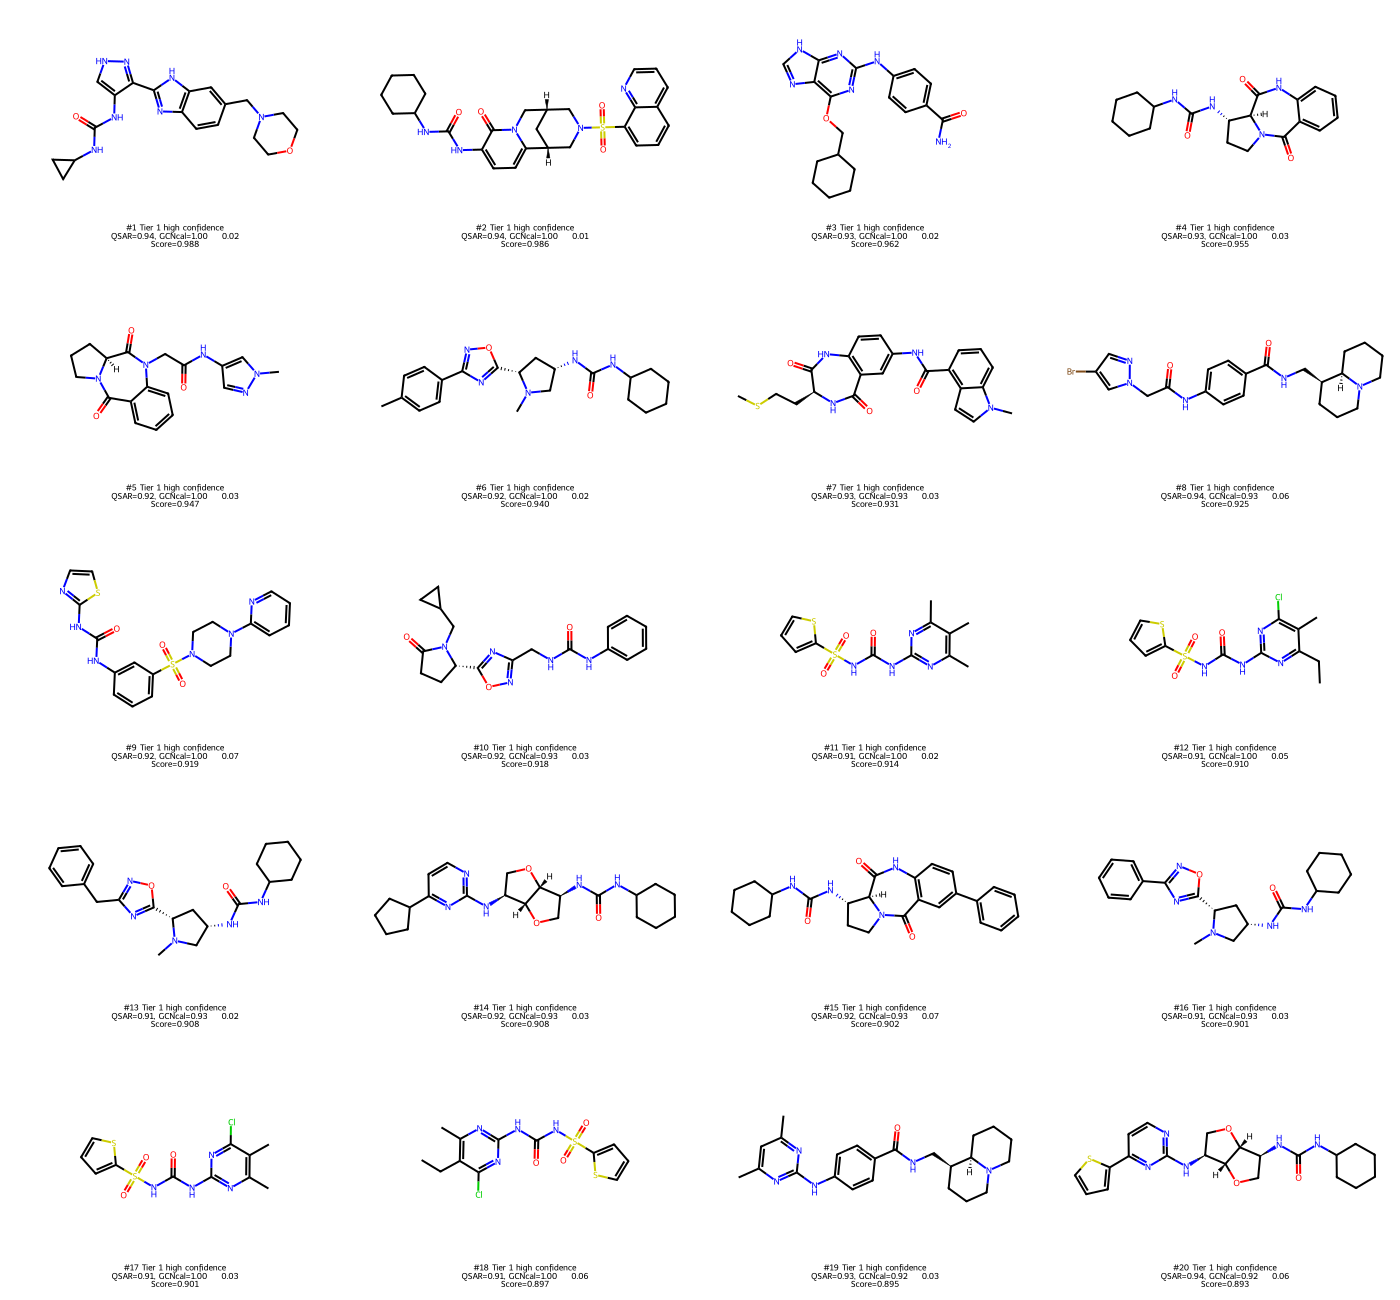

Saved: /content/drive/MyDrive/AURKB_QSAR_Publication_Ready/02_QSAR_ML_20260520_045612/03_DeepChem_GCN_Consensus_20260521_074502/figures/top20_consensus_lead_structures.png


In [32]:
# ============================================================
# 19. Draw top consensus structures
# ============================================================

draw_n = min(20, len(candidate_df))
lead_subset = candidate_df.head(draw_n).copy()
mols = [Chem.MolFromSmiles(s) for s in lead_subset["smiles"]]

legends = []
for rank, (_, row) in enumerate(lead_subset.iterrows(), start=1):
    legends.append(
        f"#{rank} {row['consensus_tier'].replace('_', ' ')}\n"
        f"QSAR={row['prob_active_qsar']:.2f}, GCNcal={row['prob_active_gcn_calibrated']:.2f}±{row['prob_active_gcn_std']:.2f}\n"
        f"Score={row['consensus_rank_score']:.3f}"
    )

img = Draw.MolsToGridImage(mols, molsPerRow=4, subImgSize=(350, 260), legends=legends)
structure_path = os.path.join(FIG_DIR, f"top{draw_n}_consensus_lead_structures.png")

try:
    img.save(structure_path)
except Exception:
    # Some RDKit builds return an IPython image object. In that case, display is still useful.
    print("Image object could not be saved directly; displaying only.")

display(img)
print(f"Saved: {structure_path}")


## 20. Generate docking-ready SDF for top candidates

This creates 3D conformers for downstream docking. Docking is not performed in this notebook to avoid mixing ligand prioritization with receptor-specific simulation settings.


In [33]:
# ============================================================
# 20. Generate docking-ready SDF for top candidates
# ============================================================

def mol_to_3d(smi, name):
    mol = Chem.MolFromSmiles(str(smi))
    if mol is None:
        return None
    mol = Chem.AddHs(mol)
    params = AllChem.ETKDGv3()
    params.randomSeed = SEED
    status = AllChem.EmbedMolecule(mol, params)
    if status != 0:
        return None
    try:
        AllChem.MMFFOptimizeMolecule(mol, maxIters=500)
    except Exception:
        try:
            AllChem.UFFOptimizeMolecule(mol, maxIters=500)
        except Exception:
            pass
    mol.SetProp("_Name", str(name))
    return mol

sdf_path = os.path.join(DEEP_RUN_DIR, f"AURKB_consensus_top{TOP_N_EXPORT}_docking_ready.sdf")
writer = Chem.SDWriter(sdf_path)
written = 0

props_to_write = [
    "prob_active_qsar",
    "prob_active_gcn_raw_mean",
    "prob_active_gcn_calibrated",
    "prob_active_gcn_std",
    "consensus_rank_score",
    "consensus_mean_probability",
    "consensus_tier",
    "max_tanimoto_to_training",
    "max_tanimoto_to_training_active",
    "QED",
    "Ro5_violations",
    "structural_alert",
]

for rank, (_, row) in enumerate(candidate_df.head(TOP_N_EXPORT).iterrows(), start=1):
    mol = mol_to_3d(row["smiles"], f"AURKB_consensus_rank_{rank}")
    if mol is not None:
        mol.SetProp("consensus_rank", str(rank))
        for prop in props_to_write:
            if prop in row.index:
                mol.SetProp(prop, str(row[prop]))
        writer.write(mol)
        written += 1

writer.close()

print(f"Docking-ready SDF molecules written: {written}/{min(TOP_N_EXPORT, len(candidate_df))}")
print(f"Saved: {sdf_path}")


Docking-ready SDF molecules written: 96/100
Saved: /content/drive/MyDrive/AURKB_QSAR_Publication_Ready/02_QSAR_ML_20260520_045612/03_DeepChem_GCN_Consensus_20260521_074502/AURKB_consensus_top100_docking_ready.sdf


## 21. Save software versions and final audit summary


In [34]:
# ============================================================
# 21. Save software versions and final audit summary
# ============================================================

software_versions = {
    "python": sys.version,
    "platform": platform.platform(),
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "rdkit": rdBase.rdkitVersion,
    "tensorflow": tf.__version__,
    "deepchem": dc.__version__,
}

with open(os.path.join(DEEP_RUN_DIR, "software_versions.json"), "w") as f:
    json.dump(software_versions, f, indent=2)

final_audit = {
    "input_files": {
        "curated_training_data": curated_path,
        "qsar_screening_candidates": screening_path,
        "qsar_model_path": qsar_model_path,
    },
    "outputs": {
        "all_consensus_candidates": all_consensus_path,
        "tier1_candidates": tier1_path,
        "top_candidates": top100_path,
        "docking_ready_sdf": sdf_path,
        "figures": FIG_DIR,
        "tables": TABLE_DIR,
        "models": MODEL_DIR,
    },
    "validation": {
        "gcn_search_metrics": search_path,
        "gcn_selected_metrics": metrics_path,
        "fingerprint_baseline_metrics": baseline_path,
        "calibrator": os.path.join(MODEL_DIR, "gcn_random_validation_isotonic_calibrator.joblib"),
    },
    "configuration": CONFIG,
    "software_versions": software_versions,
    "interpretation_note": (
        "Candidates are computationally prioritized AURKB inhibitor candidates and require "
        "docking, MD, ADMET filtering, and experimental validation before activity claims."
    ),
}

with open(os.path.join(DEEP_RUN_DIR, "final_reproducibility_audit.json"), "w") as f:
    json.dump(final_audit, f, indent=2)

print("Final audit saved.")
print(json.dumps(final_audit["outputs"], indent=2))


Final audit saved.
{
  "all_consensus_candidates": "/content/drive/MyDrive/AURKB_QSAR_Publication_Ready/02_QSAR_ML_20260520_045612/03_DeepChem_GCN_Consensus_20260521_074502/tables/AURKB_GCN_QSAR_consensus_all_candidates.csv",
  "tier1_candidates": "/content/drive/MyDrive/AURKB_QSAR_Publication_Ready/02_QSAR_ML_20260520_045612/03_DeepChem_GCN_Consensus_20260521_074502/tables/AURKB_GCN_QSAR_consensus_Tier1_high_confidence.csv",
  "top_candidates": "/content/drive/MyDrive/AURKB_QSAR_Publication_Ready/02_QSAR_ML_20260520_045612/03_DeepChem_GCN_Consensus_20260521_074502/tables/AURKB_GCN_QSAR_consensus_top100.csv",
  "docking_ready_sdf": "/content/drive/MyDrive/AURKB_QSAR_Publication_Ready/02_QSAR_ML_20260520_045612/03_DeepChem_GCN_Consensus_20260521_074502/AURKB_consensus_top100_docking_ready.sdf",
  "figures": "/content/drive/MyDrive/AURKB_QSAR_Publication_Ready/02_QSAR_ML_20260520_045612/03_DeepChem_GCN_Consensus_20260521_074502/figures",
  "tables": "/content/drive/MyDrive/AURKB_QSAR_Pub

## 22. Interpretation of the GCN and consensus results

The modelling performed in this notebook supports the following interpretation:

> A DeepChem graph convolutional neural network was trained as an orthogonal molecular-graph model to complement the descriptor-based QSAR classifier. Model generalization was evaluated using both stratified random and Bemis–Murcko scaffold-disjoint splits, and GCN performance was benchmarked against ECFP-based logistic-regression and random-forest baselines. Raw GCN probabilities were calibrated on validation predictions using isotonic regression. For candidate prioritization, the production GCN was implemented as a seed ensemble, and the standard deviation of ensemble probabilities was used as an uncertainty estimate. Final candidate prioritization required concordant calibrated QSAR and calibrated GCN evidence, QSAR applicability-domain membership, low GCN ensemble uncertainty, absence of RDKit PAINS/Brenk structural alerts, and nearest-neighbour structural support relative to the curated AURKB training set. Candidates were therefore reported as in-silico prioritized AURKB inhibitor candidates rather than experimentally confirmed inhibitors.

The compounds are not described as experimentally active; no wet-lab activity data were generated in this study.


**Saving files**

In [47]:
# ============================================================
# FINAL EXPORT CELL
# Manuscript-ready export of all tables, figures, SDF, audit files
# ============================================================

import os
import re
import json
import shutil
import zipfile
import datetime
from pathlib import Path

# -----------------------------
# 1. User-controlled settings
# -----------------------------

# Main export folder name. You can change this.
EXPORT_NAME = "AURKB_PDAC_QSAR_GCN_Manuscript_Export"

# If True, Colab will automatically download the final ZIP to your PC.
DOWNLOAD_ZIP_TO_PC = True

# If True, also keep organized export folder in Google Drive.
SAVE_ORGANIZED_FOLDER_IN_DRIVE = True

# Optional: choose where the organized folder will be saved in Google Drive.
# This does NOT affect the local PC download. The local PC download depends on your browser download settings.
EXPORT_PARENT_DRIVE = "/content/drive/MyDrive/AURKB_QSAR_Publication_Ready/Manuscript_Exports"

# -----------------------------
# 2. Detect source folders
# -----------------------------

required_vars = ["DEEP_RUN_DIR", "TABLE_DIR", "FIG_DIR"]
missing_vars = [v for v in required_vars if v not in globals()]

if missing_vars:
    raise NameError(
        f"Missing required notebook variables: {missing_vars}. "
        "Run the previous result-generation cells first."
    )

DEEP_RUN_DIR = Path(DEEP_RUN_DIR)
TABLE_DIR = Path(TABLE_DIR)
FIG_DIR = Path(FIG_DIR)

MODEL_DIR = Path(MODEL_DIR) if "MODEL_DIR" in globals() else DEEP_RUN_DIR / "gcn_models"

if not DEEP_RUN_DIR.exists():
    raise FileNotFoundError(f"DEEP_RUN_DIR not found: {DEEP_RUN_DIR}")

print("Source run folder:", DEEP_RUN_DIR)
print("Source table folder:", TABLE_DIR)
print("Source figure folder:", FIG_DIR)
print("Source model folder:", MODEL_DIR)

# -----------------------------
# 3. Create export folder
# -----------------------------

timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

if SAVE_ORGANIZED_FOLDER_IN_DRIVE:
    export_root = Path(EXPORT_PARENT_DRIVE) / f"{EXPORT_NAME}_{timestamp}"
else:
    export_root = Path("/content") / f"{EXPORT_NAME}_{timestamp}"

subfolders = {
    "main_tables": export_root / "01_Main_Manuscript_Tables",
    "main_figures": export_root / "02_Main_Manuscript_Figures",
    "supp_tables": export_root / "03_Supplementary_Tables",
    "supp_figures": export_root / "04_Supplementary_Figures",
    "lead_candidates": export_root / "05_Lead_Candidates_and_SDF",
    "audit": export_root / "06_Reproducibility_Audit_and_Config",
    "models": export_root / "07_Trained_Models_and_Calibrators",
    "raw_all": export_root / "08_All_Raw_Output_Backup",
}

for folder in subfolders.values():
    folder.mkdir(parents=True, exist_ok=True)

# -----------------------------
# 4. Helper functions
# -----------------------------

copied_records = []

def safe_copy(src, dst_folder, new_name=None, category=""):
    src = Path(src)
    dst_folder = Path(dst_folder)
    if not src.exists() or not src.is_file():
        return False

    dst_folder.mkdir(parents=True, exist_ok=True)
    dst_name = new_name if new_name else src.name
    dst = dst_folder / dst_name

    # Avoid accidental overwrite
    if dst.exists():
        stem = dst.stem
        suffix = dst.suffix
        counter = 2
        while dst.exists():
            dst = dst_folder / f"{stem}_copy{counter}{suffix}"
            counter += 1

    shutil.copy2(src, dst)

    copied_records.append({
        "category": category,
        "source": str(src),
        "destination": str(dst),
        "filename": dst.name,
        "size_bytes": dst.stat().st_size
    })
    return True

def copy_matching(source_folder, patterns, dst_folder, category):
    source_folder = Path(source_folder)
    count = 0
    for pattern in patterns:
        for f in source_folder.rglob(pattern):
            if f.is_file():
                if safe_copy(f, dst_folder, category=category):
                    count += 1
    return count

def find_files_by_keywords(source_folder, extensions, keywords_any=None, keywords_all=None):
    source_folder = Path(source_folder)
    files = []

    for ext in extensions:
        for f in source_folder.rglob(f"*{ext}"):
            name = f.name.lower()

            ok_any = True
            ok_all = True

            if keywords_any:
                ok_any = any(k.lower() in name for k in keywords_any)

            if keywords_all:
                ok_all = all(k.lower() in name for k in keywords_all)

            if ok_any and ok_all:
                files.append(f)

    return sorted(set(files))

# -----------------------------
# 5. Main manuscript tables
# -----------------------------

main_table_rules = {
    "Table_1_GCN_Selected_Model_Validation_Metrics.csv": [
        "gcn_selected_model_validation_metrics.csv"
    ],
    "Table_2_Baseline_Model_Comparison.csv": [
        "baseline_model_comparison.csv",
        "baseline_validation_metrics.csv",
        "ecfp_baseline_model_comparison.csv"
    ],
    "Table_3_Tier1A_Elite_Leads_Top50.csv": [
        "AURKB_consensus_Tier1A_elite_leads_top50.csv"
    ],
    "Table_4_Temporal_Holdout_Validation.csv": [
        "temporal_holdout_validation_ecfp_rf.csv"
    ],
    "Table_5_Bootstrap_95CI.csv": [
        "gcn_validation_bootstrap_95CI.csv"
    ],
}

for new_name, possible_names in main_table_rules.items():
    found = False
    for possible in possible_names:
        matches = list(TABLE_DIR.rglob(possible))
        if matches:
            safe_copy(matches[0], subfolders["main_tables"], new_name, "main_table")
            found = True
            break
    if not found:
        print(f"Warning: could not find expected main table: {new_name}")

# -----------------------------
# 6. Main manuscript figures
# -----------------------------

main_figure_keywords = [
    "roc",
    "pr",
    "precision",
    "recall",
    "calibration",
    "confusion",
    "tier",
    "consensus",
    "score",
    "top",
    "structure"
]

main_fig_candidates = find_files_by_keywords(
    FIG_DIR,
    extensions=[".png", ".jpg", ".jpeg", ".pdf", ".svg", ".tif", ".tiff"],
    keywords_any=main_figure_keywords
)

for f in main_fig_candidates:
    safe_copy(f, subfolders["main_figures"], category="main_figure_candidate")

# -----------------------------
# 7. Supplementary tables
# -----------------------------

# Copy all CSV/XLSX/TSV tables to supplementary table folder
supp_table_count = copy_matching(
    TABLE_DIR,
    patterns=["*.csv", "*.xlsx", "*.tsv"],
    dst_folder=subfolders["supp_tables"],
    category="supplementary_table"
)

# -----------------------------
# 8. Supplementary figures
# -----------------------------

supp_fig_count = copy_matching(
    FIG_DIR,
    patterns=["*.png", "*.jpg", "*.jpeg", "*.pdf", "*.svg", "*.tif", "*.tiff"],
    dst_folder=subfolders["supp_figures"],
    category="supplementary_figure"
)

# -----------------------------
# 9. Lead candidates, SDF, docking files
# -----------------------------

lead_patterns = [
    "*Tier1*.csv",
    "*Tier1A*.csv",
    "*top*.csv",
    "*consensus*.csv",
    "*.sdf",
    "*.mol",
    "*.mol2",
    "*.pdb",
    "*.pdbqt"
]

lead_count = 0
for pattern in lead_patterns:
    for folder in [DEEP_RUN_DIR, TABLE_DIR]:
        for f in folder.rglob(pattern):
            if f.is_file():
                if safe_copy(f, subfolders["lead_candidates"], category="lead_candidate_or_structure_file"):
                    lead_count += 1

# -----------------------------
# 10. Reproducibility audit/config files
# -----------------------------

audit_patterns = [
    "*.json",
    "*audit*.txt",
    "*audit*.csv",
    "*config*.json",
    "*summary*.txt",
    "*summary*.csv",
    "*.log"
]

audit_count = 0
for pattern in audit_patterns:
    for f in DEEP_RUN_DIR.rglob(pattern):
        if f.is_file():
            if safe_copy(f, subfolders["audit"], category="audit_or_config"):
                audit_count += 1

# -----------------------------
# 11. Models and calibrators
# -----------------------------

model_patterns = [
    "*.joblib",
    "*.pkl",
    "*.h5",
    "*.keras",
    "*.pb",
    "*.json",
    "*.index",
    "*.data-*",
    "checkpoint",
    "*.ckpt*"
]

model_count = 0
if MODEL_DIR.exists():
    for pattern in model_patterns:
        for f in MODEL_DIR.rglob(pattern):
            if f.is_file():
                if safe_copy(f, subfolders["models"], category="model_or_calibrator"):
                    model_count += 1

# -----------------------------
# 12. Full raw-output backup
# -----------------------------

# This keeps a complete copy of the original run output.
raw_backup_dir = subfolders["raw_all"] / DEEP_RUN_DIR.name
if raw_backup_dir.exists():
    shutil.rmtree(raw_backup_dir)

ignore_dirs = ["__pycache__"]
shutil.copytree(
    DEEP_RUN_DIR,
    raw_backup_dir,
    ignore=shutil.ignore_patterns(*ignore_dirs)
)

copied_records.append({
    "category": "raw_full_backup",
    "source": str(DEEP_RUN_DIR),
    "destination": str(raw_backup_dir),
    "filename": raw_backup_dir.name,
    "size_bytes": None
})

# -----------------------------
# 13. Generate README
# -----------------------------

readme_text = f"""
AURKB-PDAC QSAR-GCN Manuscript Export
Generated: {timestamp}

Source run folder:
{DEEP_RUN_DIR}

This export contains manuscript-ready organized outputs.

Folder structure:
01_Main_Manuscript_Tables
    Key tables for the main manuscript.

02_Main_Manuscript_Figures
    Candidate figures for the main manuscript.

03_Supplementary_Tables
    All generated CSV/XLSX/TSV result tables.

04_Supplementary_Figures
    All generated result figures.

05_Lead_Candidates_and_SDF
    Consensus candidate tables, Tier 1/Tier 1A tables, top-ranked compounds, and docking-ready structure files.

06_Reproducibility_Audit_and_Config
    JSON configuration files, audit files, logs, and summary outputs.

07_Trained_Models_and_Calibrators
    Saved models, calibrators, and model-related artifacts.

08_All_Raw_Output_Backup
    Complete backup copy of the original DeepChem/GCN consensus run folder.

Important interpretation:
These outputs represent computational prioritization of candidate AURKB inhibitors.
They should be interpreted as candidates for downstream docking, MD, ADMET, and experimental validation,
not as experimentally confirmed AURKB inhibitors.

Recommended manuscript use:
- Main tables: 01_Main_Manuscript_Tables
- Main figures: 02_Main_Manuscript_Figures
- Supplementary data: 03_Supplementary_Tables and 04_Supplementary_Figures
- Docking inputs: 05_Lead_Candidates_and_SDF
- Reproducibility files: 06_Reproducibility_Audit_and_Config
"""

readme_path = export_root / "README_MANUSCRIPT_EXPORT.txt"
with open(readme_path, "w", encoding="utf-8") as f:
    f.write(readme_text)

# -----------------------------
# 14. Save manifest
# -----------------------------

manifest_path = export_root / "MANIFEST_copied_files.json"
with open(manifest_path, "w", encoding="utf-8") as f:
    json.dump(copied_records, f, indent=2)

# Also save as CSV if pandas is available
try:
    import pandas as pd
    manifest_csv_path = export_root / "MANIFEST_copied_files.csv"
    pd.DataFrame(copied_records).to_csv(manifest_csv_path, index=False)
except Exception as e:
    print("Could not save CSV manifest:", e)

# -----------------------------
# 15. Create ZIP file
# -----------------------------

zip_path = Path(str(export_root) + ".zip")

if zip_path.exists():
    zip_path.unlink()

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zipf:
    for file in export_root.rglob("*"):
        if file.is_file():
            arcname = file.relative_to(export_root.parent)
            zipf.write(file, arcname)

print("\n✅ Manuscript export completed.")
print("Organized export folder:")
print(export_root)

print("\nZIP file:")
print(zip_path)

print("\nCopied file summary:")
from collections import Counter
summary = Counter([r["category"] for r in copied_records])
for k, v in summary.items():
    print(f"- {k}: {v}")

print("\nMain tables folder:")
print(subfolders["main_tables"])

print("\nMain figures folder:")
print(subfolders["main_figures"])

print("\nSupplementary tables folder:")
print(subfolders["supp_tables"])

print("\nSupplementary figures folder:")
print(subfolders["supp_figures"])

# -----------------------------
# 16. Download ZIP to local PC
# -----------------------------

if DOWNLOAD_ZIP_TO_PC:
    try:
        from google.colab import files
        print("\nStarting download to your local PC...")
        files.download(str(zip_path))
    except Exception as e:
        print("\nAutomatic download failed.")
        print("You can manually download this ZIP from the Colab file browser:")
        print(zip_path)
        print("Error:", e)

Source run folder: /content/drive/MyDrive/AURKB_QSAR_Publication_Ready/02_QSAR_ML_20260520_045612/03_DeepChem_GCN_Consensus_20260521_074502
Source table folder: /content/drive/MyDrive/AURKB_QSAR_Publication_Ready/02_QSAR_ML_20260520_045612/03_DeepChem_GCN_Consensus_20260521_074502/tables
Source figure folder: /content/drive/MyDrive/AURKB_QSAR_Publication_Ready/02_QSAR_ML_20260520_045612/03_DeepChem_GCN_Consensus_20260521_074502/figures
Source model folder: /content/drive/MyDrive/AURKB_QSAR_Publication_Ready/02_QSAR_ML_20260520_045612/03_DeepChem_GCN_Consensus_20260521_074502/gcn_models

✅ Manuscript export completed.
Organized export folder:
/content/drive/MyDrive/AURKB_QSAR_Publication_Ready/Manuscript_Exports/AURKB_PDAC_QSAR_GCN_Manuscript_Export_20260521_100324

ZIP file:
/content/drive/MyDrive/AURKB_QSAR_Publication_Ready/Manuscript_Exports/AURKB_PDAC_QSAR_GCN_Manuscript_Export_20260521_100324.zip

Copied file summary:
- main_table: 4
- main_figure_candidate: 9
- supplementary_tabl

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>